# Background

1.0 1.0974212471800975 0.9112271177267359
1.0 1.080418445901757 0.925567314953942
1.0 1.063098392832478 0.9406467047096543
1.0 1.0454402754731056 0.9565347953975257
1.0 1.027421062764124 0.9733107839055277
1.0 1.0090148345122896 0.9910657066636221
1.0 0.9901913285466947 1.0099058345296776
1.0 0.9709166349219788 1.0299545440174256
1.0 0.9511511224359892 1.0513576406648233
1.0 0.9308480386497586 1.0742892056264626
1.0 0.9099521798684095 1.0989588487436917
1.0 0.8883967438878879 1.1256232160686486
1.0 0.8660996316879775 1.1546015763233364
1.0 0.8429577583842517 1.1862990642814186
1.0 0.818838063001645 1.2212426915454602
1.0 0.7935627644298727 1.2601397706940547
1.0 0.7668836126037658 1.3039788353342752
1.0 0.7384326974672568 1.3542195564062782
1.0 0.7076160473172178 1.4131957631420264
1.0 0.6733389314082564 1.4851361674699954


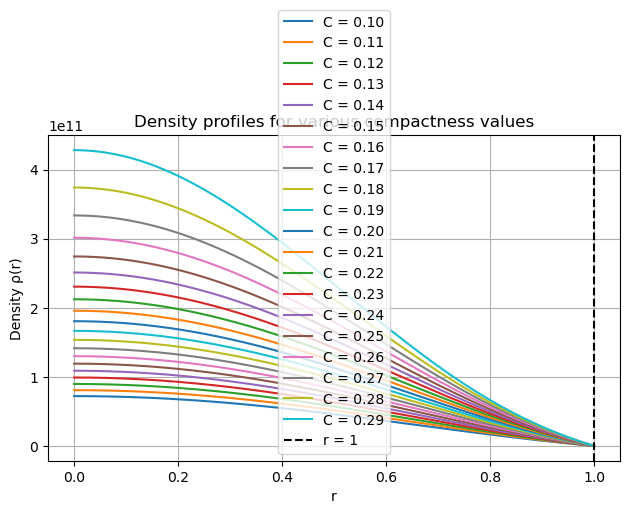

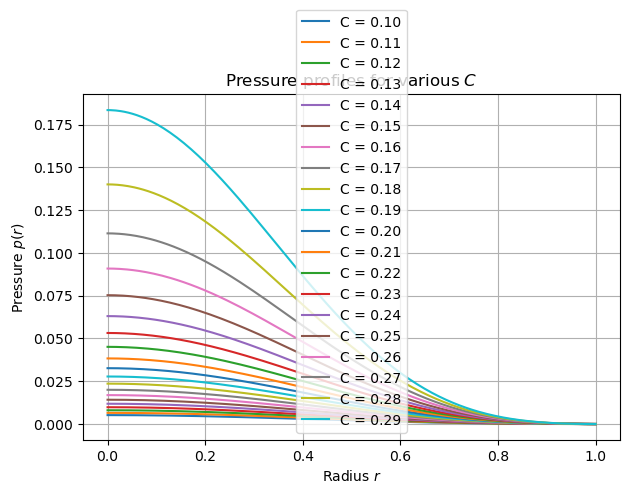

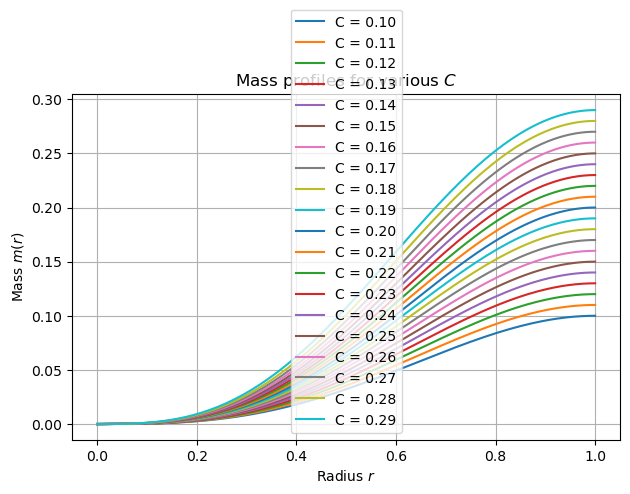

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.interpolate import InterpolatedUnivariateSpline, CubicSpline, interp1d
import matplotlib.pyplot as plt
import cmath as cm

# Constants
K = 1.0              # Polytropic constant (dimensionless)
R_target = 1.0      # Target rescaled stellar radius
n = 1                # Polytropic index


def rho_from_p(p):
    p = np.maximum(p, 0.0)
    return pow((p / K),0.5) #np.sqrt(p / K)


def tov_rhs(r, y):
    p, m,_ = y
    if p <= 0.0:
        return [0.0, 0.0,0.0]
    rho = rho_from_p(p)
    dpdr = -(rho + p) * (m + 4 * np.pi * r**3 * p) / (r * (r - 2 * m))
    dmdr = 4 * np.pi * r**2 * rho
    dnudr = -2* dpdr/(rho+p)
    return [dpdr, dmdr,dnudr]

# Solve TOV for a given p0
def solve_tov(p0):
    y0 = [p0, 0.0,0.0]
    sol = solve_ivp(
        tov_rhs,
        [1e-6, 5],  # integrate far enough to catch where p=0
        y0,
        method='RK45',
        rtol=1e-10,
        atol=1e-12,
        dense_output=True
    )
    r_vals = sol.t
    p_vals = sol.y[0]
    m_vals = sol.y[1]

    # Find where pressure becomes zero and interpolate to find R more accurately
    for i in range(1, len(p_vals)):
        if p_vals[i] <= 0:
            r1, r2 = r_vals[i-1], r_vals[i]
            p1, p2 = p_vals[i-1], p_vals[i]
            R_interp = r1 + (0 - p1) * (r2 - r1) / (p2 - p1)
            M_interp = m_vals[i-1] + (0 - p1) * (m_vals[i] - m_vals[i-1]) / (p2 - p1)
            return R_interp, M_interp, sol
    return r_vals[-1], m_vals[-1], sol  # fallback

# Shooting function to match compactness C = M/R
def shooting_target(p0, C_target):
    R, M, _ = solve_tov(p0)
    return M / R - C_target

# Define the values of compactness to solve for
C_vals = np.round(np.arange(0.10, 0.30, 0.01), 2)
profiles = {}

for C_target in C_vals:
    soln = root_scalar(
        shooting_target,
        args=(C_target,),
        bracket=[1e-6, 1.0],
        method='brentq',
        xtol=1e-12
    )

    if not soln.converged:
        raise RuntimeError(f"Root finding failed for C = {C_target}")

    p0 = soln.root
    R_raw, M_raw, sol = solve_tov(p0)
    scale_factor = R_target / R_raw
    print(R_target, R_raw, scale_factor)
    """
    # Interpolate full solution on new scaled r grid
    r_vals = sol.t * scale_factor
    p_vals = sol.y[0]*scale_factor**2

    m_vals = sol.y[1] * scale_factor
    rho_vals = rho_from_p(p_vals)
    """
    scale_factor = R_target / R_raw  # alpha

    r_vals = sol.t * scale_factor           # r -> alpha * r   (correct)
    p_vals = sol.y[0] * scale_factor**(-2)  # p -> alpha^{-2} * p    <-- FIXED
    m_vals = sol.y[1] * scale_factor        # m -> alpha * m         (correct)
    rho_vals = rho_from_p(p_vals)           # consistent with p
    nu_vals = sol.y[2]
    # Truncate where p goes to zero
    mask = p_vals > 0
    r_vals = r_vals[mask]
    p_vals = p_vals[mask]
    m_vals = m_vals[mask]
    rho_vals = rho_vals[mask]
    nu_vals = nu_vals[mask]
    #print(np.min(r_vals))
    # after you have scaled/truncated and have:
    # === Normalize nu(r) to match exterior Schwarzschild metric ===
    R = R_raw * scale_factor
    M = M_raw * scale_factor

    if 2.0 * M / R >= 1.0:
        raise ValueError(f"Unphysical compactness encountered for C = {C_target}: 2M/R >= 1")

    nu_target_surface = np.log(1.0 - 2.0 * M / R)
    nu_raw_surface = nu_vals[-1]

    # Compute constant shift Δν
    delta_nu = nu_target_surface - nu_raw_surface

    # Apply the shift to entire profile
    nu_vals_normalized = nu_vals + delta_nu

    # Optional: check that the matching condition is satisfied
    #print(f"C = {C_target:.2f} | nu_surface (raw) = {nu_raw_surface:.6f}, "f"target = {nu_target_surface:.6f}, shift = {delta_nu:.6f}")

    profiles[C_target] = {
        'r': r_vals,
        'r_raw': R_raw,
        'p': p_vals,
        'm': m_vals,
        'rho': rho_vals,
        'nu': nu_vals,
        'nu_vals_norm': nu_vals_normalized,
        'p0': p0,
        'R': R_raw * scale_factor,
        'M': M_raw * scale_factor,
        'M_raw': M_raw
    }


for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['rho']*1e12, label=f'C = {C:.2f}')
plt.axvline(1.0, color='black', linestyle='--', label='r = 1')
plt.xlabel('r')
plt.ylabel('Density ρ(r)')
plt.title('Density profiles for various compactness values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pressure
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,2)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['p'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Pressure $p(r)$')
plt.title('Pressure profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Mass
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,3)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['m'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Mass $m(r)$')
plt.title('Mass profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
r_vals = []
M_vals = []

for i in profiles:
    r_vals.append(profiles[i]['r_raw'])
    M_vals.append(profiles[i]['M_raw'])

In [1]:
c = 3e8  # speed of light in m/s
G = 6.67430e-11  # gravitational constant in m^3 kg^-1 s^-2
M_solar = 2e30 #kg 



In [2]:
(G/c**2)*10*M_solar

14831.777777777777

In [69]:
1.3**2

1.6900000000000002

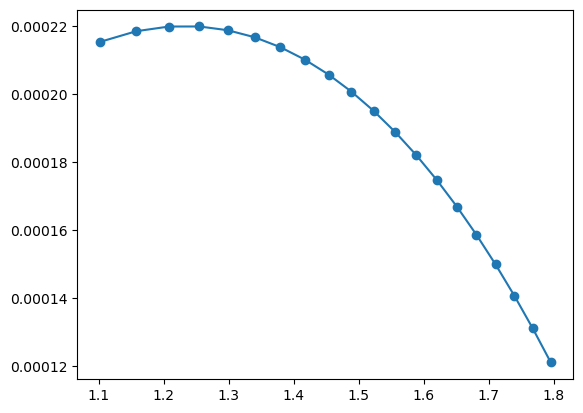

In [70]:
plt.plot((18/11)*np.array(r_vals), (18/11)*scaling*np.array(M_vals), marker='o')

In [66]:
((G/c**2)**2)/(1e4)**2 

5.499540801234567e-63

# Rest mass TOV

1.0 1.0624668681804987 0.9412058201047955
1.0 1.0410426907534356 0.9605754008764696
1.0 1.0190457848784027 0.981310177461089
1.0 0.9964190003731127 1.0035938692714073
1.0 0.9730931607860098 1.0276508358071865
1.0 0.948984168366809 1.0537583590261455
1.0 0.9239873094981035 1.0822659464264563
1.0 0.897969484161089 1.11362358926287
1.0 0.8707561290125269 1.1484271734429718
1.0 0.8421095899111956 1.1874938986331396
1.0 0.8116902298128915 1.2319970886313576
1.0 0.7789786425240836 1.283732242978771
1.0 0.7430990681119909 1.345715588825489
1.0 0.7023197600330895 1.423852861484184


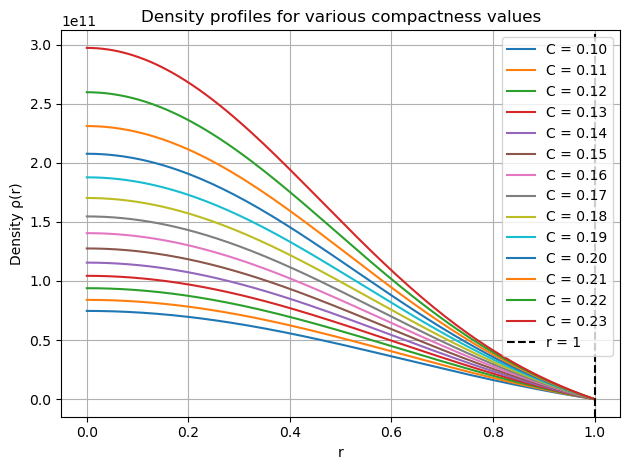

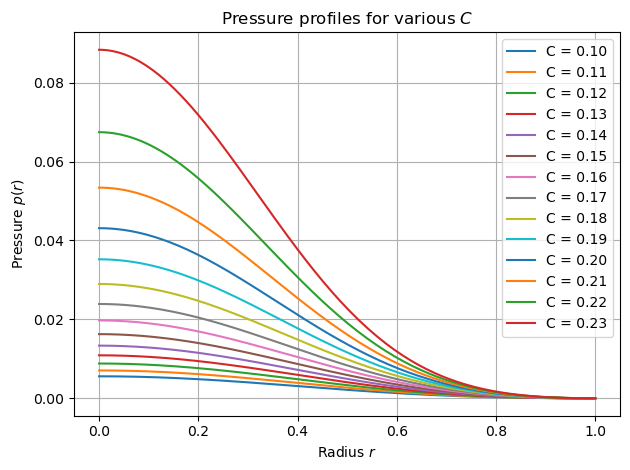

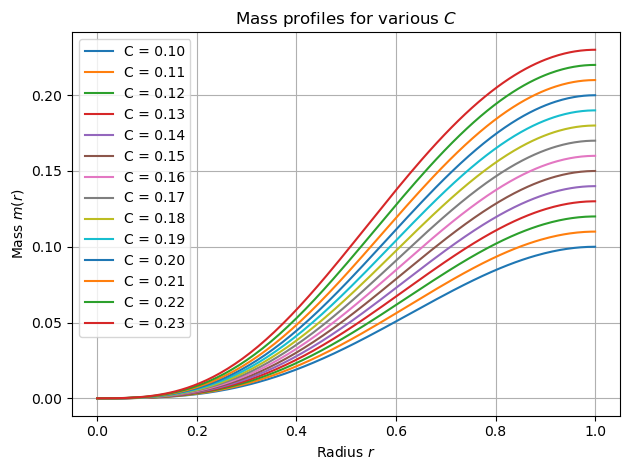

In [89]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.interpolate import InterpolatedUnivariateSpline, CubicSpline, interp1d
import matplotlib.pyplot as plt
import cmath as cm

# Constants
K = 1.0             # Polytropic constant (dimensionless)
R_target = 1.0      # Target rescaled stellar radius
n = 1                # Polytropic index


"""def rho_from_p(p):
    p = np.maximum(p, 0.0)
    return pow((p / K),0.5) #np.sqrt(p / K)"""

def rho_from_p(p):
    return np.sqrt(np.maximum(p, 0.0) / K)

def energy_density_from_p(p):
    rho0 = rho_from_p(p)
    Gamma = 1 + 1/n
    return rho0 + (p/(Gamma-1))  # Total energy density for polytropic EOS


def tov_rhs(r, y):
    p, m, nu = y

    if p <= 0.0:
        return [0.0, 0.0, 0.0]

    rho0 = rho_from_p(p)
    eps  = energy_density_from_p(p) #rho0 + p  # total energy density

    dpdr = -(eps + p) * (m + 4*np.pi*r**3*p) / (r*(r - 2*m))
    dmdr = 4*np.pi * r**2 * eps
    dnudr = -2 * dpdr / (eps + p)

    return [dpdr, dmdr, dnudr]


# Solve TOV for a given p0
def solve_tov(p0, epsi_p = 1e-12): #changing to check for p_cut dependency
    y0 = [p0, 0.0,0.0]
    sol = solve_ivp(
        tov_rhs,
        [1e-6, 10],  # integrate far enough to catch where p=0
        y0,
        method='RK45',
        rtol=1e-10,
        atol=1e-12,
        dense_output=True
    )
    r_vals = sol.t
    p_vals = sol.y[0]
    m_vals = sol.y[1]
    
    p_cut = epsi_p * p0
    # Find where pressure becomes zero and interpolate to find R more accurately
    for i in range(1, len(p_vals)):
        if p_vals[i] <= p_cut:
            r1, r2 = r_vals[i-1], r_vals[i]
            p1, p2 = p_vals[i-1], p_vals[i]
            R_interp = r1 + (p_cut - p1) * (r2 - r1) / (p2 - p1)
            M_interp = m_vals[i-1] + (p_cut - p1) * (m_vals[i] - m_vals[i-1]) / (p2 - p1)
            return R_interp, M_interp, sol
    return r_vals[-1], m_vals[-1], sol  # fallback

# Shooting function to match compactness C = M/R
def shooting_target(p0, C_target):
    R, M, _ = solve_tov(p0)
    return M / R - C_target

# Define the values of compactness to solve for
C_vals = np.round(np.arange(0.10, 0.24, 0.01), 2)
profiles = {}


for C_target in C_vals:
    soln = root_scalar(
        shooting_target,
        args=(C_target,),
        bracket=[1e-6, 1.0],
        method='brentq',
        xtol=1e-12
    )

    if not soln.converged:
        raise RuntimeError(f"Root finding failed for C = {C_target}")

    p0 = soln.root
    R_raw, M_raw, sol = solve_tov(p0)
    scale_factor = R_target / R_raw
    print(R_target, R_raw, scale_factor)

    scale_factor = R_target / R_raw  # alpha

    r_vals = sol.t * scale_factor           # r -> alpha * r   (correct)
    p_vals = sol.y[0] * scale_factor**(-2)  # p -> alpha^{-2} * p    <-- FIXED
    m_vals = sol.y[1] * scale_factor        # m -> alpha * m         (correct)
    rho_vals = rho_from_p(p_vals)           # consistent with p
    nu_vals = sol.y[2]
    # Truncate where p goes to zero
    """
    mask = p_vals > p_cut
    r_vals = r_vals[mask]
    p_vals = p_vals[mask]
    m_vals = m_vals[mask]
    rho_vals = rho_vals[mask]
    nu_vals = nu_vals[mask]
    """
    
    mask = r_vals <= R_target
    r_vals = r_vals[mask]
    p_vals = p_vals[mask]
    m_vals = m_vals[mask]
    rho_vals = rho_vals[mask]
    nu_vals = nu_vals[mask]
    
    R = R_raw * scale_factor
    M = M_raw * scale_factor

    if 2.0 * M / R >= 1.0:
        raise ValueError(f"Unphysical compactness encountered for C = {C_target}: 2M/R >= 1")

    nu_target_surface = np.log(1.0 - 2.0 * M / R)
    nu_raw_surface = nu_vals[-1]

    # Compute constant shift Δν
    delta_nu = nu_target_surface - nu_raw_surface

    # Apply the shift to entire profile
    nu_vals_normalized = nu_vals + delta_nu


    profiles[C_target] = {
        'r': r_vals,
        'r_raw': R_raw,
        'p': p_vals,
        'm': m_vals,
        'rho': rho_vals,
        'nu': nu_vals,
        'nu_vals_norm': nu_vals_normalized,
        'p0': p0,
        'R': R_raw * scale_factor,
        'M': M_raw * scale_factor,
        'M_raw': M_raw
    }


for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['rho']*1e12, label=f'C = {C:.2f}')
plt.axvline(1.0, color='black', linestyle='--', label='r = 1')
plt.xlabel('r')
plt.ylabel('Density ρ(r)')
plt.title('Density profiles for various compactness values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pressure
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,2)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['p'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Pressure $p(r)$')
plt.title('Pressure profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Mass
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,3)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['m'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Mass $m(r)$')
plt.title('Mass profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

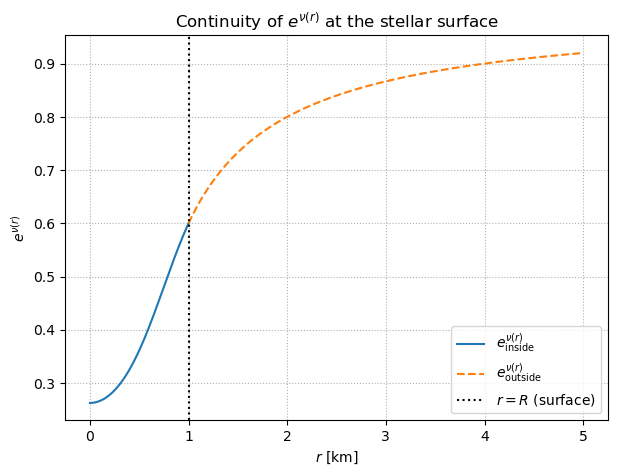

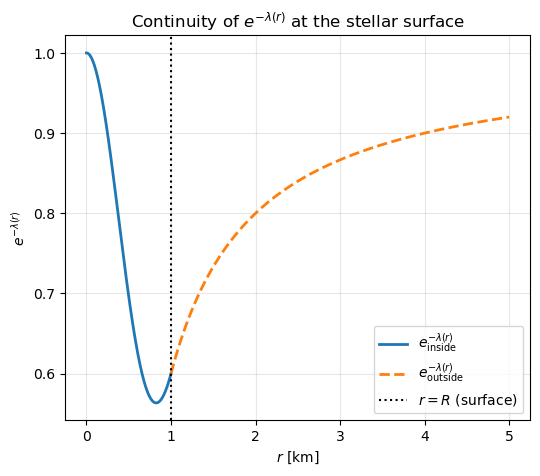

In [82]:
import numpy as np
import matplotlib.pyplot as plt
C = 0.2

M = profiles[C]['M']
R = profiles[C]['R']
nu_in = profiles[C]['nu_vals_norm']
r_in = profiles[C]['r']
m = profiles[C]['m']

def nu_out(r):
    return np.log(1 - 2*M/r)


exp_nu_in = np.exp(nu_in)
r_out = np.linspace(R, 5*R, 200)
exp_nu_out = np.exp(nu_out(r_out))


plt.figure(figsize=(7,5))
plt.plot(r_in, exp_nu_in, label=r'$e^{\nu(r)}_{\mathrm{inside}}$', color='tab:blue')
plt.plot(r_out, exp_nu_out, label=r'$e^{\nu(r)}_{\mathrm{outside}}$', color='tab:orange', linestyle='--')

plt.axvline(R, color='k', linestyle=':', label=r'$r=R$ (surface)')
plt.xlabel(r'$r$ [km]')
plt.ylabel(r'$e^{\nu(r)}$')
plt.title('Continuity of $e^{\\nu(r)}$ at the stellar surface')
plt.legend()
plt.grid(True, ls=':')
plt.show()


elam_inside = 1 - 2 * m / r_in

r_out = np.linspace(R, 5 * R, 200)
elam_outside = 1 - 2 * M / r_out

plt.figure(figsize=(6,5))
plt.plot(r_in, elam_inside, label=r"$e^{-\lambda(r)}_{\rm inside}$", lw=2)
plt.plot(r_out, elam_outside, '--', label=r"$e^{-\lambda(r)}_{\rm outside}$", lw=2)
plt.axvline(R, color='k', ls=':', label=r"$r = R$ (surface)")
plt.xlabel(r"$r$ [km]")
plt.ylabel(r"$e^{-\lambda(r)}$")
plt.title(r"Continuity of $e^{-\lambda(r)}$ at the stellar surface")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Axial interior

# Polar interior

In [83]:
class ComplexSpline:
    def __init__(self, x, y, k=3):
        self.real_spline = CubicSpline(x, np.real(y))
        self.imag_spline = CubicSpline(x, np.imag(y))

    def __call__(self, x):
        return self.real_spline(x) + 1j * self.imag_spline(x)

    def derivative(self, n=1):
        der_real = self.real_spline.derivative(n)
        der_imag = self.imag_spline.derivative(n)
        return lambda x: der_real(x) + 1j * der_imag(x)


def lambda_of_r(r, m):
    m_vals = m(r) if callable(m) else m
    return -np.log(1.0 - 2.0 * m_vals / r)

profile= profiles[0.2]
T = 1e5 #Temperature
Ke = 4e25 / (T/1e5)**2 #cgs g cm^-1 s^-1
G = 6.67e-8
c = 3e10
conv = G/c**3
R_n = 1e6 # 10 km

def make_bg_splines(profile):
    r = profile['r']
    m = profile['m']
    p = profile['p']
    rho = profile['rho']
    nu = CubicSpline(r,profile['nu_vals_norm'])
    lam = CubicSpline(r, lambda_of_r(r,m))
    pprime = (CubicSpline(r,p)).derivative()
    rhoprime = (CubicSpline(r,rho)).derivative()
    cs2 = CubicSpline(r, (pprime(r)/rhoprime(r)))

    return {
        'r': r,
        'm': CubicSpline(r,m),
        'p': CubicSpline(r,p),
        'p_prime': pprime ,
        'rho': CubicSpline(r,rho),
        'rho_prime': rhoprime,
        'nu': nu,
        'lam': lam,
        'lam_p': lam.derivative(),
        'nu_p': nu.derivative(),
        's': 0,
        'sp': 0,
        'cs2': cs2
    }


Ken = 1e-7*(1/10)#Ke*conv * R_n; #cgs -> geometric cm^-1  # Arbitrary here we can set this to any value elsewhere
eps = 1e-6
rho_sat =  2.8e14 #cgs
bg = make_bg_splines(profile)
r_vals, m_spline, p_spline, rho_spline, nu_spline = bg['r'], bg['m'], bg['p'], bg['rho'], bg['nu']

r_end = bg['r'][bg['p'](bg['r']) > 0][-1] - 1e-4
rho_vals      = rho_spline(r_vals)
rho_cgs_vals  = rho_vals * 1.4e16
rho_cgs_spline = ComplexSpline(r_vals, rho_cgs_vals, k=3)

# Derivatives
rho_prime_spline  = rho_spline.derivative()
rho_2prime_spline = rho_spline.derivative(2)

rho_cgs_prime_spline  = rho_cgs_spline.derivative()
rho_cgs_2prime_spline = rho_cgs_spline.derivative(2)

nu_prime_spline = nu_spline.derivative()
p_prime_spline  = p_spline.derivative()

nu0 = nu_spline(eps)
p0 = p_spline(eps)
rho0 = rho_spline(eps)
lambd2 = 8*np.pi*rho0/3
elambd0 = lambda_of_r(eps,m_spline)

def p2o(r):
    return -0.5*(p0+rho0) *4*np.pi*(p0 + (rho0/3))
def rho2o(r):
    return p2o(r)/(p_prime_spline(eps)/rho_prime_spline(eps))
def nu2o(r):
    return (4*np.pi/3)*(rho0+3*p0)

In [84]:
r_end = bg['r'][bg['p'](bg['r']) > 0][-1] - 1e-4

def make_bg_tables(bg, r_grid):
    return {
        'r': r_grid,
        'm': bg['m'](r_grid),
        'p': bg['p'](r_grid),
        'rho': bg['rho'](r_grid),
        'nu': bg['nu'](r_grid),
        'lam': bg['lam'](r_grid),
        'lam_p': bg['lam_p'](r_grid),
        'nu_p': bg['nu_p'](r_grid),
        'p_prime': bg['p_prime'](r_grid),
        'rho_prime': bg['rho_prime'](r_grid),
        'cs2': bg['cs2'](r_grid),
    }

def pack_bg_quantities(bg_tab):

    return np.vstack([
        bg_tab['m'],
        bg_tab['p'],
        bg_tab['rho'],
        bg_tab['nu'],
        bg_tab['lam'],
        bg_tab['lam_p'],
        bg_tab['nu_p'],
        bg_tab['p_prime'],
        bg_tab['rho_prime'],
        bg_tab['cs2'],
    ])

r_tab = np.linspace(eps, r_end, 4000)


class SourceTensor:
  def S01(self, r, omega): return 0.0
  def S01p(self, r, omega): return 0.0
  def S00(self, r, omega): return 0.0
  def S0A(self, r, omega): return 0.0
  def SZ(self, r, omega): return 0.0
  def S0(self, r, omega): return 0.0
  def S0p(self, r, omega): return 0.0
  def S1(self, r, omega): return 0.0
  def S1p(self, r, omega): return 0.0
  def SOm(self, r, omega): return 0.0

def make_source(source, r_grid, omega):

    return {
        'S01':  np.asarray([source.S01(r,  omega) for r in r_grid]),
        'S01p': np.asarray([source.S01p(r, omega) for r in r_grid]),
        'S00':  np.asarray([source.S00(r,  omega) for r in r_grid]),
        'S0A':  np.asarray([source.S0A(r,  omega) for r in r_grid]),
        'SZ':   np.asarray([source.SZ(r,   omega) for r in r_grid]),
        'S0':   np.asarray([source.S0(r,   omega) for r in r_grid]),
        'S0p':  np.asarray([source.S0p(r,  omega) for r in r_grid]),
        'S1':   np.asarray([source.S1(r,   omega) for r in r_grid]),
        'S1p':  np.asarray([source.S1p(r,  omega) for r in r_grid]),
        'SOm':  np.asarray([source.SOm(r,  omega) for r in r_grid]),
    }

def pack_source(source_tables):
    return np.vstack([source_tables[k] for k in ('S01','S01p','S00','S0A','SZ','S0','S0p','S1','S1p','SOm')])


from numba import njit

@njit()
def interp(r, r_grid, f_grid):
    i = np.searchsorted(r_grid, r) - 1
    if i < 0:
        i = 0
    if i >= r_grid.size - 1:
        i = r_grid.size - 2

    r0 = r_grid[i]
    r1 = r_grid[i+1]
    f0 = f_grid[i]
    f1 = f_grid[i+1]

    return f0 + (f1 - f0) * (r - r0) / (r1 - r0)

def init_conds_even_perfect(r, om, s=True):
   pi = cm.pi
   Whinit = 1*r**3
   if s==True:
    Kinit = +(rho0+p0)*r**2
   else:
     Kinit = -(rho0+p0)*r**2
   Xinit = (1/6)*cm.exp(-nu0/2)*(p0+rho0)*(-3*om**2 *Whinit + cm.exp(nu0)*(3*Kinit + 8*pi*Whinit*(3*p0+rho0))) *r**2     #((cm.exp(3*nu0/2)*pi*(3*p0**2 + 4*p0*rho0 + rho0**2))/(om**2 + 2*cm.exp(nu0)*pi*(3*p0 + rho0)))*eps**2
   H1init = (2/3)*(Kinit + 4*pi*Whinit)*(p0+rho0) *r**3                                                                  #((32*cm.exp(nu0)*pi**2 *Whinit*(p0+rho0)*(3*p0+rho0))/(9*om**2))*eps**3
   return np.array([Xinit.real, Xinit.imag, Whinit.real, Whinit.imag, H1init.real, H1init.imag, Kinit.real, Kinit.imag])
       
  


print(init_conds_even_perfect(eps, 0.5))


#Old init conds: [3.85586324e-14 0.00000000e+00 2.13262475e-19 0.00000000e+00 5.17056176e-37 0.00000000e+00 1.00000000e-12 0.00000000e+00]


[1.61111795e-26 0.00000000e+00 1.00000000e-18 0.00000000e+00
 4.19234005e-32 0.00000000e+00 2.50762736e-13 0.00000000e+00]


In [85]:
def evenSystem(r, y, om, bg,source: SourceTensor, l=2):
  Xhre, Xhim, Whre, Whim, H1re, H1im, Kre, Kim = y
  pi = cm.pi

  Xh = Xhre + 1j*Xhim
  Wh = Whre + 1j*Whim
  H1 = H1re + 1j*H1im
  K = Kre + 1j*Kim

  S01 = source.S01(r, om)
  S00 = source.S00(r, om)
  S0A = source.S0A(r, om)
  SZ  = source.SZ(r,  om)
  S0  = source.S0(r,  om)
  S1  = source.S1(r,  om)
  SOm = source.SOm(r, om)
  S01p = source.S01p(r,om)
  S0p = source.S0p(r, om)
  S1p = source.S1p(r,om)
  drhods = 0

  m, p, rho, nu, lam, lam_p, nu_p, p_prime, rho_prime, s, sp, cs2 = bg['m'](r), bg['p'](r), bg['rho'](r), bg['nu'](r), bg['lam'](r), bg['lam_p'](r), bg['nu_p'](r), bg['p_prime'](r), bg['rho_prime'](r), bg['s'], bg['sp'], bg['cs2'](r)


  #Sighnum = cm.exp(-lam + (nu/2))*(2*cm.exp(lam)*r*om*S00*rho + p *(2*cm.exp(lam)*r*om*S00 + 1j*(12*cm.exp(lam)*S0A - 2*r* S01p + S01*(-4+r*lam_p - r*nu_p))) + 1j*(2*rho*(6*cm.exp(lam)*S0A - r*S01p) + S01*(2*r*n0*T*sp + rho*(-4+r*lam_p - r*nu_p))))
  Sigh = 0 #Sighnum/(2*r**3 *om*n0*T*(rho+p))

  Eh = (Xh/cs2) + drhods*Sigh


  Hdenom = 3*m + ((l+2)*(l-1)/2)*r + 4*pi*r**3 *p
  H = (-((l*(l+1)/2)*(m + 4*pi*r**3 *p) - om**2 *r**3 *cm.exp(-lam-nu))*H1 + (((l+2)*(l-1)/2)*r - om**2 *r**3 *cm.exp(-nu) - (cm.exp(lam)/r) *(m+4*pi*r**3 *p)*(3*m-r+4*pi*r**3 *p)) * K + 8*pi*r**3 *cm.exp(-nu/2) * Xh - 8*pi*r*S0 - 16*pi*r*cm.exp(-lam)*S1)/Hdenom

  Vhnum1 = cm.exp(-lam + (nu/2))*(cm.exp(lam) * r**2 * H *(p+rho) + 2*(-2*cm.exp(lam)*SZ + cm.exp(lam)*SOm + S1*(2+cm.exp(lam)+4*cm.exp(lam)*r**2 *(p-rho)) - cm.exp(lam/2)*r*Wh*p_prime + r*S1p))
  Vhnum2 = cm.exp(nu/2) *(2*Xh - (Vhnum1/r**2))
  Vh = Vhnum2/(2*om**2 *(rho+p))

  dH1dr = (cm.exp(lam)/r) * H + (4*pi*r*(rho-p)*cm.exp(lam) - (2*m*cm.exp(lam)/r**2) - (3/r))*H1 + (cm.exp(lam)/r)*K - 16*pi*((rho+p)/r)*cm.exp(lam)*Vh + 16*pi*(cm.exp(lam)/r) * SZ
  dKdr = (H/r) + (l*(l+1)/2*r) *H1 + ((nu_p/2) - ((l+1)/r))*K - 8*pi*((rho+p)/r)*cm.exp(lam/2)*Wh + (16*pi/r)*SZ
  dWhdr = (r/2)*cm.exp(lam/2)*H + r*cm.exp(lam/2)*K + (r*cm.exp((lam-nu)/2)/(rho+p)) * Eh - Wh*(l+1)/r -(l*(l+1)/r)*cm.exp(lam/2)*Vh - cm.exp(lam/2)*S00/(r*(rho+p)) + 8*pi*r*cm.exp(lam/2)*SZ
  dXhdr = ((rho+p)/2)*cm.exp(nu/2)*(0.5-(nu_p/2))*H + ((rho+p)/2)*cm.exp(nu/2)*(om**2 *r*cm.exp(-nu) + (l*(l+1)/2*r))*H1 + ((rho+p)/2)*cm.exp(nu/2)*((3*nu_p/2)-(1/r))*K - (l/r)*Xh - ((rho+p)/2)*cm.exp((lam+nu)/2)*(om**2 *cm.exp(-nu) + (cm.exp(-lam)/4*r**2) *(cm.exp(2*lam)*(1+8*pi*r**2 *p)**2 + 2*cm.exp(lam)*(3 + 8*pi*r**2 *p - 7)) )*Wh + (l*(l+1)/r**2)*cm.exp(nu/2)*p_prime*Vh + (cm.exp(nu/2)/(2*r**3))*(2*l-1 +cm.exp(lam)*(1+8*pi*r**2 *p))*S0 + (cm.exp(nu/2)/r**2)*S0p - (cm.exp(nu/2)/r**3)*(l*(l+1) + 8*pi*r**2 *(rho+p))*S1 - (2*cm.exp(nu/2)/r**3)*SOm


  return np.array([dXhdr.real, dXhdr.imag, dWhdr.real, dWhdr.imag, dH1dr.real, dH1dr.imag, dKdr.real, dKdr.imag])



In [86]:
@njit
def evenSystem_zoom(r, y, om, r_grid, bg_tab, source, l=2):
    Xhre, Xhim, Whre, Whim, H1re, H1im, Kre, Kim = y
    pi = cm.pi
    Xh = Xhre + 1j*Xhim
    Wh = Whre + 1j*Whim
    H1 = H1re + 1j*H1im
    K = Kre + 1j*Kim

    m = interp(r, r_grid, bg_tab[0])
    p = interp(r, r_grid, bg_tab[1])
    rho = interp(r, r_grid, bg_tab[2])
    nu = interp(r, r_grid, bg_tab[3])
    lam = interp(r, r_grid, bg_tab[4])
    lam_p = interp(r, r_grid, bg_tab[5])
    nu_p = interp(r, r_grid, bg_tab[6])
    p_prime = interp(r, r_grid, bg_tab[7])
    rho_prime = interp(r, r_grid, bg_tab[8])
    cs2 = interp(r, r_grid, bg_tab[9])
    
    if np.all(source == 0):
        S01 = 0.0
        S01p = 0.0
        S00 = 0.0
        S0A = 0.0
        SZ = 0.0
        S0 = 0.0
        S0p = 0.0
        S1 = 0.0
        S1p = 0.0
        SOm = 0.0
    else:
        S01  = interp(r, r_grid, source[0])
        S01p = interp(r, r_grid, source[1])
        S00  = interp(r, r_grid, source[2])
        S0A  = interp(r, r_grid, source[3])
        SZ   = interp(r, r_grid, source[4])
        S0   = interp(r, r_grid, source[5])
        S0p  = interp(r, r_grid, source[6])
        S1   = interp(r, r_grid, source[7])
        S1p  = interp(r, r_grid, source[8])
        SOm  = interp(r, r_grid, source[9])

    
    #Sighnum = cm.exp(-lam + (nu/2))*(2*cm.exp(lam)*r*om*S00*rho + p *(2*cm.exp(lam)*r*om*S00 + 1j*(12*cm.exp(lam)*S0A - 2*r* S01p + S01*(-4+r*lam_p - r*nu_p))) + 1j*(2*rho*(6*cm.exp(lam)*S0A - r*S01p) + S01*(2*r*n0*T*sp + rho*(-4+r*lam_p - r*nu_p))))
    Sigh = 0 #Sighnum/(2*r**3 *om*n0*T*(rho+p))
    drhods = 0

    Eh = (Xh/cs2) + drhods*Sigh


    Hdenom = r*(2*r + 3*m + 4*pi*r**3 *p) #3*m + ((l+2)*(l-1)/2)*r + 4*pi*r**3 *p
    H = (8*pi*r**4 * Xh * cm.exp(-nu/2) + 2*r**2 *K - cm.exp(-nu)*r**4 *om**2 *K + cm.exp(lam)*r*K*m - 3*cm.exp(lam)*K*m**2 + 4*cm.exp(lam)*pi*r**4 *p*K - 16*cm.exp(lam)*pi*r**3 *K *m*p - 16*cm.exp(lam)*pi**2 *r**6 *K *p**2 + H1*(-3*r*m + r**4 *(cm.exp(-lam-nu)*om**2 - 12*pi*p)) - 8*pi*r**2 *S0 - 16*cm.exp(-lam)*pi*r**2 *S1)/Hdenom #(-((l*(l+1)/2)*(m + 4*pi*r**3 *p) - om**2 *r**3 *cm.exp(-lam-nu))*H1 + (((l+2)*(l-1)/2)*r - om**2 *r**3 *cm.exp(-nu) - (cm.exp(lam)/r) *(m+4*pi*r**3 *p)*(3*m-r+4*pi*r**3 *p)) * K + 8*pi*r**3 *cm.exp(-nu/2) * Xh - 8*pi*r*S0 - 16*pi*r*cm.exp(-lam)*S1)/Hdenom

    Vhnum1 = cm.exp(-lam + (nu/2))*(cm.exp(lam) * r**2 * H *(p+rho) + 2*(-2*cm.exp(lam)*SZ + cm.exp(lam)*SOm + S1*(2+cm.exp(lam)+4*cm.exp(lam)*r**2 *(p-rho)) - cm.exp(lam/2)*r*Wh*p_prime + r*S1p))
    Vhnum2 = cm.exp(nu/2) *(2*Xh - (Vhnum1/r**2))
    Vh = Vhnum2/(2*om**2 *(rho+p))

    dH1dr = (cm.exp(lam)/r) * H + (4*pi*r*(rho-p)*cm.exp(lam) - (2*m*cm.exp(lam)/r**2) - (3/r))*H1 + (cm.exp(lam)/r)*K - 16*pi*((rho+p)/r)*cm.exp(lam)*Vh + 16*pi*(cm.exp(lam)/r) * SZ
    dKdr = (H/r) + (l*(l+1)/2*r) *H1 + ((nu_p/2) - ((l+1)/r))*K - 8*pi*((rho+p)/r)*cm.exp(lam/2)*Wh + (16*pi/r)*SZ
    dWhdr = (r/2)*cm.exp(lam/2)*H + r*cm.exp(lam/2)*K + (r*cm.exp((lam-nu)/2)/(rho+p)) * Eh - Wh*(l+1)/r -(l*(l+1)/r)*cm.exp(lam/2)*Vh - cm.exp(lam/2)*S00/(r*(rho+p)) + 8*pi*r*cm.exp(lam/2)*SZ
    dXhdr = ((rho+p)/2)*cm.exp(nu/2)*(0.5-(nu_p/2))*H + ((rho+p)/2)*cm.exp(nu/2)*(om**2 *r*cm.exp(-nu) + (l*(l+1)/2*r))*H1 + ((rho+p)/2)*cm.exp(nu/2)*((3*nu_p/2)-(1/r))*K - (l/r)*Xh - ((rho+p)/2)*cm.exp((lam+nu)/2)*(om**2 *cm.exp(-nu) + (cm.exp(-lam)/4*r**2) *(cm.exp(2*lam)*(1+8*pi*r**2 *p)**2 + 2*cm.exp(lam)*(3 + 8*pi*r**2 *p - 7)) )*Wh + (l*(l+1)/r**2)*cm.exp(nu/2)*p_prime*Vh + (cm.exp(nu/2)/(2*r**3))*(2*l-1 +cm.exp(lam)*(1+8*pi*r**2 *p))*S0 + (cm.exp(nu/2)/r**2)*S0p - (cm.exp(nu/2)/r**3)*(l*(l+1) + 8*pi*r**2 *(rho+p))*S1 - (2*cm.exp(nu/2)/r**3)*SOm
    


    return np.array([dXhdr.real, dXhdr.imag, dWhdr.real, dWhdr.imag, dH1dr.real, dH1dr.imag, dKdr.real, dKdr.imag])


def even_wrapper(r, y, om, r_grid, bg_tab, source):
    return evenSystem_zoom(r, y, om, r_grid, bg_tab, source, l=2)

def EvenSolver_zoom(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(make_bg_tables(bg_tab, r_grid))
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3
    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol

def EvenSolverNumbaZerilli(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(make_bg_tables(bg_tab, r_grid))
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3
    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol.t[-1], sol.y[:,-1]


M, nuR = bg['m'](1), bg['nu'](1)





In [22]:
constraint_log = []
# temporary turnofff @njit
def evenSystem_zoom_check(r, y, om, r_grid, bg_tab, source, l=2):
    Xhre, Xhim, Whre, Whim, H1re, H1im, Kre, Kim = y
    pi = cm.pi
    Xh = Xhre + 1j*Xhim
    Wh = Whre + 1j*Whim
    H1 = H1re + 1j*H1im
    K = Kre + 1j*Kim

    m = interp(r, r_grid, bg_tab[0])
    p = interp(r, r_grid, bg_tab[1])
    rho = interp(r, r_grid, bg_tab[2])
    nu = interp(r, r_grid, bg_tab[3])
    lam = interp(r, r_grid, bg_tab[4])
    lam_p = interp(r, r_grid, bg_tab[5])
    nu_p = interp(r, r_grid, bg_tab[6])
    p_prime = interp(r, r_grid, bg_tab[7])
    rho_prime = interp(r, r_grid, bg_tab[8])
    cs2 = interp(r, r_grid, bg_tab[9])
    
    if np.all(source == 0):
        S01 = 0.0
        S01p = 0.0
        S00 = 0.0
        S0A = 0.0
        SZ = 0.0
        S0 = 0.0
        S0p = 0.0
        S1 = 0.0
        S1p = 0.0
        SOm = 0.0
    else:
        S01  = interp(r, r_grid, source[0])
        S01p = interp(r, r_grid, source[1])
        S00  = interp(r, r_grid, source[2])
        S0A  = interp(r, r_grid, source[3])
        SZ   = interp(r, r_grid, source[4])
        S0   = interp(r, r_grid, source[5])
        S0p  = interp(r, r_grid, source[6])
        S1   = interp(r, r_grid, source[7])
        S1p  = interp(r, r_grid, source[8])
        SOm  = interp(r, r_grid, source[9])

    
    #Sighnum = cm.exp(-lam + (nu/2))*(2*cm.exp(lam)*r*om*S00*rho + p *(2*cm.exp(lam)*r*om*S00 + 1j*(12*cm.exp(lam)*S0A - 2*r* S01p + S01*(-4+r*lam_p - r*nu_p))) + 1j*(2*rho*(6*cm.exp(lam)*S0A - r*S01p) + S01*(2*r*n0*T*sp + rho*(-4+r*lam_p - r*nu_p))))
    Sigh = 0 #Sighnum/(2*r**3 *om*n0*T*(rho+p))
    drhods = 0

    Eh = (Xh/cs2) + drhods*Sigh


    Hdenom = r*(2*r + 3*m + 4*pi*r**3 *p) #3*m + ((l+2)*(l-1)/2)*r + 4*pi*r**3 *p
    H = (8*pi*r**4 * Xh * cm.exp(-nu/2) + 2*r**2 *K - cm.exp(-nu)*r**4 *om**2 *K + cm.exp(lam)*r*K*m - 3*cm.exp(lam)*K*m**2 + 4*cm.exp(lam)*pi*r**4 *p*K - 16*cm.exp(lam)*pi*r**3 *K *m*p - 16*cm.exp(lam)*pi**2 *r**6 *K *p**2 + H1*(-3*r*m + r**4 *(cm.exp(-lam-nu)*om**2 - 12*pi*p)) - 8*pi*r**2 *S0 - 16*cm.exp(-lam)*pi*r**2 *S1)/Hdenom #(-((l*(l+1)/2)*(m + 4*pi*r**3 *p) - om**2 *r**3 *cm.exp(-lam-nu))*H1 + (((l+2)*(l-1)/2)*r - om**2 *r**3 *cm.exp(-nu) - (cm.exp(lam)/r) *(m+4*pi*r**3 *p)*(3*m-r+4*pi*r**3 *p)) * K + 8*pi*r**3 *cm.exp(-nu/2) * Xh - 8*pi*r*S0 - 16*pi*r*cm.exp(-lam)*S1)/Hdenom

    Vhnum1 = cm.exp(-lam + (nu/2))*(cm.exp(lam) * r**2 * H *(p+rho) + 2*(-2*cm.exp(lam)*SZ + cm.exp(lam)*SOm + S1*(2+cm.exp(lam)+4*cm.exp(lam)*r**2 *(p-rho)) - cm.exp(lam/2)*r*Wh*p_prime + r*S1p))
    Vhnum2 = cm.exp(nu/2) *(2*Xh - (Vhnum1/r**2))
    Vh = Vhnum2/(2*om**2 *(rho+p))

    dH1dr = (cm.exp(lam)/r) * H + (4*pi*r*(rho-p)*cm.exp(lam) - (2*m*cm.exp(lam)/r**2) - (3/r))*H1 + (cm.exp(lam)/r)*K - 16*pi*((rho+p)/r)*cm.exp(lam)*Vh + 16*pi*(cm.exp(lam)/r) * SZ
    dKdr = (H/r) + (l*(l+1)/2*r) *H1 + ((nu_p/2) - ((l+1)/r))*K - 8*pi*((rho+p)/r)*cm.exp(lam/2)*Wh + (16*pi/r)*SZ
    dWhdr = (r/2)*cm.exp(lam/2)*H + r*cm.exp(lam/2)*K + (r*cm.exp((lam-nu)/2)/(rho+p)) * Eh - Wh*(l+1)/r -(l*(l+1)/r)*cm.exp(lam/2)*Vh - cm.exp(lam/2)*S00/(r*(rho+p)) + 8*pi*r*cm.exp(lam/2)*SZ
    dXhdr = ((rho+p)/2)*cm.exp(nu/2)*(0.5-(nu_p/2))*H + ((rho+p)/2)*cm.exp(nu/2)*(om**2 *r*cm.exp(-nu) + (l*(l+1)/2*r))*H1 + ((rho+p)/2)*cm.exp(nu/2)*((3*nu_p/2)-(1/r))*K - (l/r)*Xh - ((rho+p)/2)*cm.exp((lam+nu)/2)*(om**2 *cm.exp(-nu) + (cm.exp(-lam)/4*r**2) *(cm.exp(2*lam)*(1+8*pi*r**2 *p)**2 + 2*cm.exp(lam)*(3 + 8*pi*r**2 *p - 7)) )*Wh + (l*(l+1)/r**2)*cm.exp(nu/2)*p_prime*Vh + (cm.exp(nu/2)/(2*r**3))*(2*l-1 +cm.exp(lam)*(1+8*pi*r**2 *p))*S0 + (cm.exp(nu/2)/r**2)*S0p - (cm.exp(nu/2)/r**3)*(l*(l+1) + 8*pi*r**2 *(rho+p))*S1 - (2*cm.exp(nu/2)/r**3)*SOm
    
    H_lhs = (
        r*(2*r + 3*m + 4*pi*r**3*p)*H
        - (
            8*pi*r**4 * Xh * cm.exp(-nu/2)
            + 2*r**2 *K
            - cm.exp(-nu)*r**4 *om**2 *K
            + cm.exp(lam)*r*K*m
            - 3*cm.exp(lam)*K*m**2
            + 4*cm.exp(lam)*pi*r**4 *p*K
            - 16*cm.exp(lam)*pi*r**3 *K *m*p
            - 16*cm.exp(lam)*pi**2 *r**6 *K *p**2
            + H1*(-3*r*m + r**4 *(cm.exp(-lam-nu)*om**2 - 12*pi*p))
            - 8*pi*r**2 *S0
            - 16*cm.exp(-lam)*pi*r**2 *S1
        )
    )
    # --- V constraint residual ---

    V_lhs = (
        2*om**2*(rho+p)*Vh
        - cm.exp(nu/2) * (
            2*Xh
            - (1/r**2) * (
                cm.exp(-lam + (nu/2)) * (
                    cm.exp(lam) * r**2 * H *(p+rho)
                    + 2*(-2*cm.exp(lam)*SZ
                        + cm.exp(lam)*SOm
                        + S1*(2+cm.exp(lam)+4*cm.exp(lam)*r**2*(p-rho))
                        - cm.exp(lam/2)*r*Wh*p_prime
                        + r*S1p)
                )
            )
        )
    )
    constraint_log.append((r, np.abs(H_lhs), np.abs(V_lhs)))

    return np.array([dXhdr.real, dXhdr.imag, dWhdr.real, dWhdr.imag, dH1dr.real, dH1dr.imag, dKdr.real, dKdr.imag])


def even_wrapper_check(r, y, om, r_grid, bg_tab, source):
    return evenSystem_zoom_check(r, y, om, r_grid, bg_tab, source, l=2)

def EvenSolver_zoom(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(make_bg_tables(bg_tab, r_grid))
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper_check(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3
    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol





In [87]:
r_tab

array([1.00000000e-06, 2.51036971e-04, 5.01073942e-04, ...,
       9.99398773e-01, 9.99648810e-01, 9.99898847e-01])

(0,)
(6038, 3)


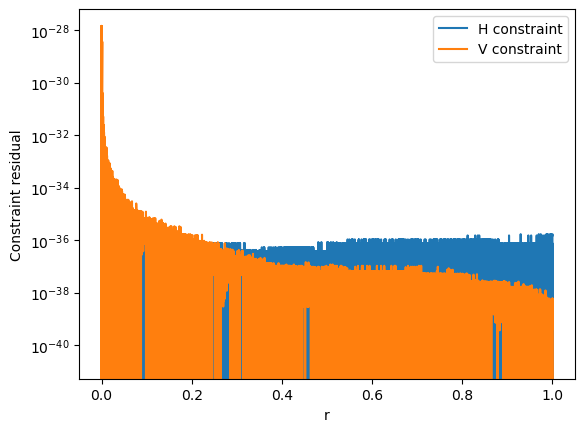

In [30]:
constraint_log = []
print(np.array(constraint_log).shape)
solution = EvenSolver_zoom(1.5-0.35j, r_tab, bg)
print(np.array(constraint_log).shape)

constraint_log = np.array(constraint_log)

plt.semilogy(constraint_log[:,0], constraint_log[:,1], label='H constraint')
plt.semilogy(constraint_log[:,0], constraint_log[:,2], label='V constraint')
plt.xlabel('r')
plt.ylabel('Constraint residual')
plt.legend()
del solution, constraint_log

# CF ready implementation

In [88]:
bg_tab = make_bg_tables(bg, r_tab)

def EvenSolverNumbaZerilli(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(bg_tab)
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3
    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol.t[-1], sol.y[:,-1]


import cmath as cm

def Zerilli(omega, R, sol_surface, bg_tab, l=2):

    M   = bg_tab['m'][-1]
    nuR = bg_tab['nu'][-1]

    #XhR = sol_surface[0] + 1j * sol_surface[1]
    #WhR = sol_surface[2] + 1j * sol_surface[3]
    H1R = sol_surface[4] + 1j * sol_surface[5]
    KR  = sol_surface[6] + 1j * sol_surface[7]
    f = 1 - (2*M)/R

    lam = (l - 1) * (l + 2)
    D   = lam * R + 6.0 * M

    ZR = R**3 *((2*M-R)*H1R + R*KR)/(3*M + 2*R)  #(R**l * (2.0 * R**2 / D)   * (KR - cm.exp(nuR) * H1R)   )

    dZR = (R**2 *(6*(2*M**3 + M**2 *R + M*R**2 - R**3)*H1R + R*(-3*M**2 - 6*M*R + 2*R**2)*KR))/((2*M-R)*(3*M + 2*R)**2)   #(1/f) * ( R**l * (  ( 2.0 * lam * R**2 - 6.0 * M * (lam * R + 2.0 * M) ) * KR   + cm.exp(2.0 * nuR)  * (  lam * l * (l + 1) * R**2 + 6.0 * M * (lam * R + 4.0 * M)   ) * H1R ) / D**2   )
    #
    return ZR, dZR

def ZerilliR(omega, R, sol_surface, bg_tab):
    return Zerilli(omega, R, sol_surface, bg_tab, l=2)


def Chandrasekhar(om, Z, dZ, R, M, l=2):
    A = (l*(l+1)/2) - 1
    B = 6*M
    Kappa = 4*A*(A+1)
    f = 1 - (2*M)/R
    F = (R-2*M)/(2*R**2 *(A*R + 3*M))

    QR = ((Kappa + 2*B**2 *F)*Z - (2*B*f)*dZ)/(Kappa - 2j *B*om)

    dQR = (-2*B*(-om**2 + Kappa*F + B**2 *F**2)*Z + (Kappa + 2*B**2 *F)*f*dZ)/(Kappa - 2j *B*om)

    return QR, dQR


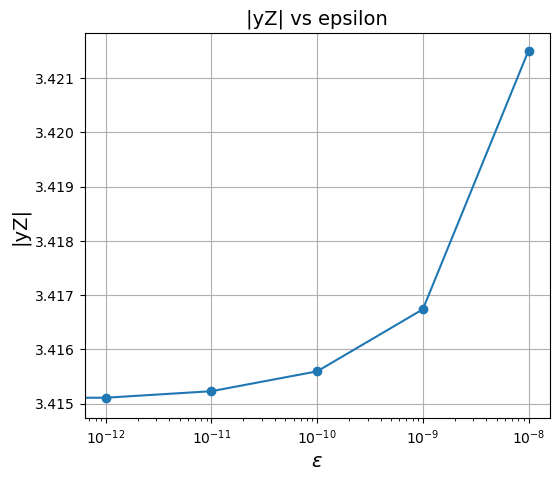

In [126]:
def build_profiles(epsi_p):

    profiles = {}

    for C_target in C_vals:

        soln = root_scalar(
            shooting_target,
            args=(C_target,),
            bracket=[1e-6, 1.0],
            method='brentq',
            xtol=1e-12
        )

        p0 = soln.root
        R_raw, M_raw, sol = solve_tov(p0, epsi_p=epsi_p)

        scale_factor = R_target / R_raw

        r_vals = sol.t * scale_factor
        p_vals = sol.y[0] * scale_factor**(-2)
        m_vals = sol.y[1] * scale_factor
        rho_vals = rho_from_p(p_vals)
        nu_vals = sol.y[2]

        mask = r_vals <= R_target
        M = M_raw * scale_factor
        R = R_raw * scale_factor
        nu_target_surface = np.log(1.0 - 2.0 * M / R)
        nu_raw_surface = nu_vals[-1]

        # Compute constant shift Δν
        delta_nu = nu_target_surface - nu_raw_surface

        # Apply the shift to entire profile
        nu_vals_normalized = nu_vals + delta_nu


        profiles[C_target] = {
            'r': r_vals,
            'r_raw': R_raw,
            'p': p_vals,
            'm': m_vals,
            'rho': rho_vals,
            'nu': nu_vals,
            'nu_vals_norm': nu_vals_normalized,
            'p0': p0,
            'R': R_raw * scale_factor,
            'M': M_raw * scale_factor,
            'M_raw': M_raw
        }


    return profiles

eps_list = sorted([1e-8, 1e-9, 1e-10, 1e-11, 1e-12,0])


omega = 0.1   # example test frequency

C_test = 0.2   # choose compactness

plt.figure(figsize=(6,5))
yZ_vals = []
for eps in eps_list:

    profiles = build_profiles(eps)

    profile = profiles[C_test]
    activate_profile(profile)


    M = profile['M']
    R = profile['R']
    C = M/R

    sol_surface = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1]
    ZR, dZR = ZerilliR(omega, R, sol_surface, bg_tab)

    yZ = (2*M/(1-2*C))*(dZR/ZR)
    yZ_vals.append(np.abs(yZ.real))

plt.semilogx(eps_list, yZ_vals, marker='o')


plt.xlabel(r"$\epsilon$", fontsize=14)
plt.ylabel("|yZ|", fontsize=14)
plt.title(f"|yZ| vs epsilon", fontsize=14)
plt.grid(True)

plt.show()


In [127]:
profile

{'r': array([1.23218216e-06, 6.42435334e-04, 1.22061912e-03, 2.95376956e-03,
        5.03817952e-03, 7.32505815e-03, 9.75395257e-03, 1.22999041e-02,
        1.49493278e-02, 1.76933245e-02, 2.05256118e-02, 2.34416464e-02,
        2.64381456e-02, 2.95127853e-02, 3.26639936e-02, 3.58908009e-02,
        3.91927276e-02, 4.25696963e-02, 4.60219619e-02, 4.95500545e-02,
        5.31547329e-02, 5.68369446e-02, 6.05977929e-02, 6.44385079e-02,
        6.83604224e-02, 7.23649502e-02, 7.64535674e-02, 8.06277958e-02,
        8.48891882e-02, 8.92393141e-02, 9.36797475e-02, 9.82120542e-02,
        1.02837780e-01, 1.07558440e-01, 1.12375504e-01, 1.17290387e-01,
        1.22304434e-01, 1.27418912e-01, 1.32634991e-01, 1.37953735e-01,
        1.43376091e-01, 1.48902875e-01, 1.54534762e-01, 1.60272285e-01,
        1.66115821e-01, 1.72065598e-01, 1.78121693e-01, 1.84284040e-01,
        1.90552440e-01, 1.96926576e-01, 2.03406029e-01, 2.09990303e-01,
        2.16678837e-01, 2.23471039e-01, 2.30366299e-01, 2.3

In [129]:
2*M/(1-2*C)

np.float64(0.6668335070168427)

In [148]:
from tqdm import tqdm

In [149]:
om_list = np.linspace(1e-3, 4, 50)   # example range of frequencies
yZ_vals = []
for omega in tqdm(om_list):

    M = profile['M']
    R = profile['R']
    C = M/R

    sol_surface = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1]
    ZR, dZR = ZerilliR(omega, R, sol_surface, bg_tab)

    yZ = (2*M/(1-2*C))*(dZR/ZR)
    yZ_vals.append(np.abs(yZ))



  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:53<00:00,  1.08s/it]


In [150]:
np.array(yZ_vals)/(2*M/(1-2*C))

array([  4.76966646,   5.10535955,   5.61262569,   2.74048464,
        12.50855026,   2.43646654,   7.85654376,  13.56724212,
         5.49374841,   7.85587197,   1.72290299,   3.79717737,
         0.78198864,   1.4158731 ,   1.01766885,   3.34219054,
        12.24523582,  55.48455548,  13.1822072 ,   9.41020892,
        10.65074786,   7.4662922 ,   8.00943635,   8.77882611,
         9.89488934,  11.4697988 ,  13.71225226,  17.02921428,
        22.29041342,  31.70401789,  52.94713717, 143.45130508,
       239.67896846,  68.77269554,  41.39913866,  30.25412841,
        24.22189045,  20.44685575,  17.86285022,  15.98122378,
        14.54640838,  13.41175129,  12.48711043,  11.71407668,
        11.05320174,  10.47694897,   9.96557905,   9.50463331,
         9.08333087,   8.69351134])

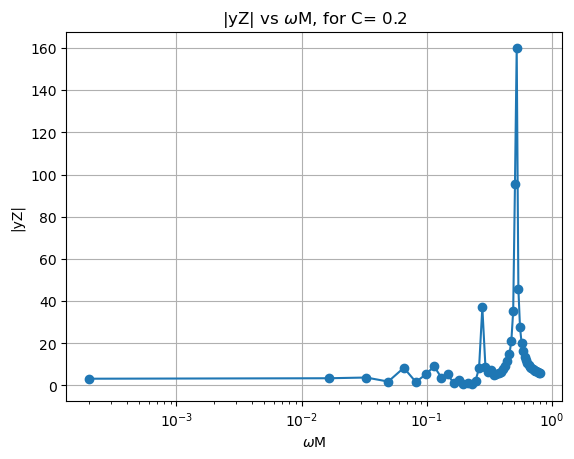

In [151]:
plt.semilogx(om_list*M, yZ_vals, marker='o')
plt.xlabel(r"$\omega$M")
plt.ylabel("|yZ|")
plt.title(f"|yZ| vs $\omega$M, for C= 0.2")
plt.grid(True)
plt.show()

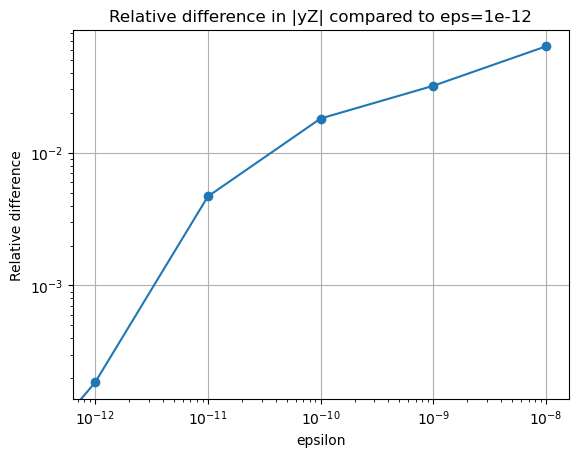

In [ ]:


for eps in eps_list:
    profiles = build_profiles(eps)
    profile = profiles[C_test]
    activate_profile(profile)

    sol_surface = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1]
    ZR, dZR = ZerilliR(omega, R, sol_surface, bg_tab)

    yZ_values.append(np.abs((2*M/(1-2*C))*(dZR/ZR)))

yZ_ref = yZ_values[0]  # use eps=1e-12 as reference

diffs = [abs(y - yZ_ref)/yZ_ref for y in yZ_values]

plt.loglog(eps_list, diffs, 'o-')
plt.xlabel("epsilon")
plt.ylabel("Relative difference")
plt.title("Relative difference in |yZ| compared to eps=1e-12")
plt.grid(True)
plt.show()


In [144]:
activate_profile(profiles[0.2])

In [28]:
ZerilliR(0.5, R, EvenSolverNumbaZerilli(0.5, r_tab, bg_tab)[1], bg_tab=bg_tab)

(np.complex128(1.7546613595806151e-19+0j),
 np.complex128(-3.3715746748585766e-18+0j))

In [18]:
Zr, dZr = ZerilliR(0.5, R, EvenSolverNumbaZerilli(0.5, r_tab, bg_tab)[1], bg_tab=bg_tab)

In [ ]:
Z, dZ = ZerilliR(2, R, EvenSolverNumbaZerilli(1, r_tab, bg_tab)[1], bg_tab=bg_tab)
print("Z = ", Z)
print("dZ = ", dZ)
print("Z'/Z at 1:", (2*M/(1-2*C))*dZ/Z, "for om = 1")
del Z, dZ

Z =  (6.987664573137688e-20+0j)
dZ =  (7.040867879549632e-20-0j)
Z'/Z at 1: (0.6718098373083258+0j) for om = 1


In [ ]:
Z, dZ = ZerilliR(1, R, EvenSolverNumbaZerilli(1, r_tab, bg_tab)[1], bg_tab=bg_tab)
print("Z = ", Z)
print("dZ = ", dZ)
print("Z'/Z at 1:", dZ/Z, "for om = 1")
del Z, dZ

Z =  (8.127331567118963e-20+0j)
dZ =  (5.3752511852846885e-20-0j)
Z'/Z at 1: (0.6613795857709971-0j) for om = 1


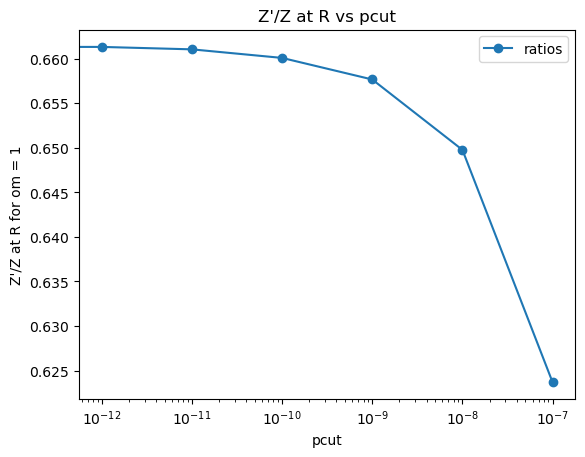

In [70]:
pcutvals = np.array([0, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7])
ratios = np.array([0.6613795857709971-0j, 0.6613131504686663-0j, 0.6610399249211438-0j, 0.6600789291920196-0j, 0.6576582118733794-0j, 0.6497598617675249-0j, 0.6236765472465771-0j])

plt.semilogx(pcutvals, np.real(ratios), label='ratios', marker='o')
plt.xlabel('pcut')
plt.ylabel('Z\'/Z at R for om = 1')
plt.title('Z\'/Z at R vs pcut')
plt.legend()


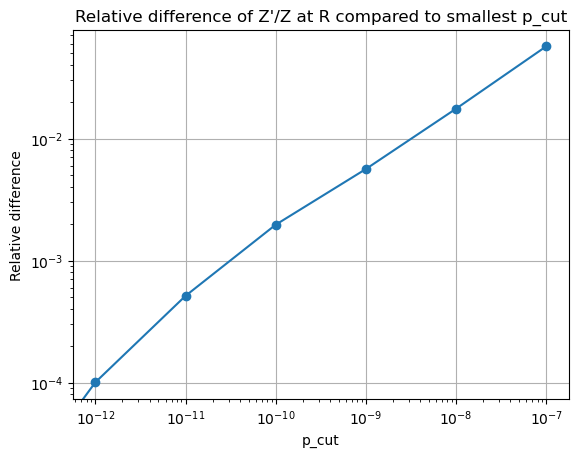

In [71]:
ref = ratios[0] # assuming first element is smallest p_cut

rel_diff = np.abs((ratios - ref) / ref)

plt.loglog(pcutvals, rel_diff, 'o-')
plt.xlabel('p_cut')
plt.ylabel('Relative difference')
plt.title('Relative difference of Z\'/Z at R compared to smallest p_cut')
plt.grid(True)
plt.show()


# log derivative testing

In [7]:
import numpy as np
from tqdm import tqdm

def Z_ratio(omega, R, r_tab, bg_tab):
    """
    Compute Z'/Z at the surface for a given omega.
    """
    # integrate interior
    sol_surface = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1]

    # compute Zerilli variable at surface
    ZR, dZR = ZerilliR(omega, R, sol_surface, bg_tab)

    # avoid division explosion
    ratio = dZR / ZR

    if not np.isfinite(ratio.real) or not np.isfinite(ratio.imag):
        return np.nan + 1j*np.nan

    return ratio


import matplotlib.pyplot as plt

def plot_Zratio_heatmap(Re_range, Im_range, n_re, n_im, R, r_tab, bg_tab):
    Re_vals = np.linspace(*Re_range, n_re)
    Im_vals = np.linspace(*Im_range, n_im)

    grid = np.zeros((n_re, n_im), dtype=np.float64)

    for i, re in enumerate(tqdm(Re_vals)):
        for j, im in enumerate(Im_vals):
            omega = re + 1j*im
            Rval = Z_ratio(omega, R, r_tab, bg_tab)

            if np.isnan(Rval.real):
                grid[i,j] = np.nan
            else:
                grid[i,j] = np.log10(abs(Rval) + 1e-30)

    plt.figure(figsize=(6,5))
    plt.imshow(
        grid.T,
        extent=[Re_vals[0], Re_vals[-1], Im_vals[0], Im_vals[-1]],
        origin='lower',
        aspect='auto',
        cmap='viridis'
    )
    plt.colorbar(label=r'$\log_{10}|Z^\prime/Z|$')
    plt.xlabel(r'Re$(\omega)$')
    plt.ylabel(r'Im$(\omega)$')
    plt.title(r'Heatmap of $\log|Z^\prime/Z|$')
    plt.show()

    return Re_vals, Im_vals, grid

def plot_Zratio_phase(Re_range, Im_range, n_re, n_im, R, r_tab, bg_tab):
    Re_vals = np.linspace(*Re_range, n_re)
    Im_vals = np.linspace(*Im_range, n_im)

    phase_grid = np.zeros((n_re, n_im))

    for i, re in enumerate(tqdm(Re_vals)):
        for j, im in enumerate(Im_vals):
            omega = re + 1j*im
            Rval = Z_ratio(omega, R, r_tab, bg_tab)

            if np.isnan(Rval.real):
                phase_grid[i,j] = np.nan
            else:
                phase_grid[i,j] = np.angle(Rval)

    plt.figure(figsize=(6,5))
    plt.imshow(
        phase_grid.T,
        extent=[Re_vals[0], Re_vals[-1], Im_vals[0], Im_vals[-1]],
        origin='lower',
        aspect='auto',
        cmap='twilight'
    )
    plt.colorbar(label=r'$\arg(Z^\prime/Z)$')
    plt.xlabel(r'Re$(\omega)$')
    plt.ylabel(r'Im$(\omega)$')
    plt.title(r'Phase of $Z^\prime/Z$')
    plt.show()

    return Re_vals, Im_vals, phase_grid

def plot_Zratio_trajectory_real_line(re_range, im_fixed, n_points, R, r_tab, bg_tab):
    re_vals = np.linspace(*re_range, n_points)
    traj = []

    for re in re_vals:
        omega = re + 1j*im_fixed
        traj.append(Z_ratio(omega, R, r_tab, bg_tab))

    traj = np.array(traj)

    plt.figure(figsize=(5,5))
    plt.plot(traj.real, traj.imag)
    plt.xlabel(r'Re$(Z^\prime/Z)$')
    plt.ylabel(r'Im$(Z^\prime/Z)$')
    plt.title(f'Argand trajectory, Im(ω)={im_fixed}')
    plt.axhline(0, color='k', lw=0.5)
    plt.axvline(0, color='k', lw=0.5)
    plt.gca().set_aspect('equal', 'box')
    plt.show()

def plot_Zratio_trajectory_im_line(im_range, re_fixed, n_points, R, r_tab, bg_tab):
    im_vals = np.linspace(*im_range, n_points)
    traj = []

    for im in im_vals:
        omega = re_fixed + 1j*im
        traj.append(Z_ratio(omega, R, r_tab, bg_tab))

    traj = np.array(traj)

    plt.figure(figsize=(5,5))
    plt.plot(traj.real, traj.imag)
    plt.xlabel(r'Re$(Z^\prime/Z)$')
    plt.ylabel(r'Im$(Z^\prime/Z)$')
    plt.title(f'Argand trajectory, Re(ω)={re_fixed}')
    plt.axhline(0, color='k', lw=0.5)
    plt.axvline(0, color='k', lw=0.5)
    plt.gca().set_aspect('equal', 'box')
    plt.show()


In [20]:
Re_range = (0.1, 3.0)
Im_range = (-2.0, 0.0)


100%|██████████| 50/50 [21:36<00:00, 25.94s/it]


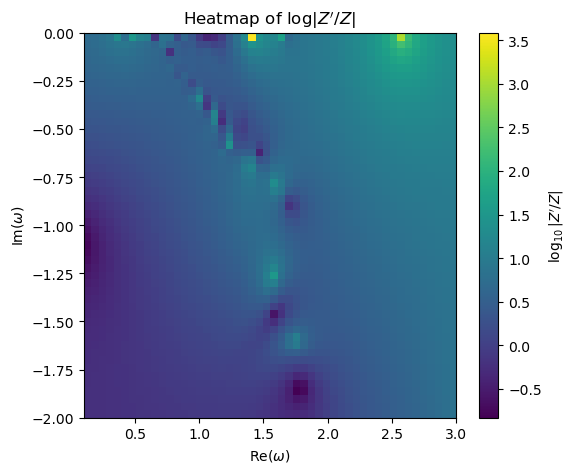

(array([0.1       , 0.15918367, 0.21836735, 0.27755102, 0.33673469,
        0.39591837, 0.45510204, 0.51428571, 0.57346939, 0.63265306,
        0.69183673, 0.75102041, 0.81020408, 0.86938776, 0.92857143,
        0.9877551 , 1.04693878, 1.10612245, 1.16530612, 1.2244898 ,
        1.28367347, 1.34285714, 1.40204082, 1.46122449, 1.52040816,
        1.57959184, 1.63877551, 1.69795918, 1.75714286, 1.81632653,
        1.8755102 , 1.93469388, 1.99387755, 2.05306122, 2.1122449 ,
        2.17142857, 2.23061224, 2.28979592, 2.34897959, 2.40816327,
        2.46734694, 2.52653061, 2.58571429, 2.64489796, 2.70408163,
        2.76326531, 2.82244898, 2.88163265, 2.94081633, 3.        ]),
 array([-2.        , -1.95918367, -1.91836735, -1.87755102, -1.83673469,
        -1.79591837, -1.75510204, -1.71428571, -1.67346939, -1.63265306,
        -1.59183673, -1.55102041, -1.51020408, -1.46938776, -1.42857143,
        -1.3877551 , -1.34693878, -1.30612245, -1.26530612, -1.2244898 ,
        -1.18367347, -1.14

In [21]:
plot_Zratio_heatmap(Re_range, Im_range, 50, 50, 1.01*R, r_tab, bg_tab)

In [8]:
Z, dZ = ZerilliR(1, R, EvenSolverNumbaZerilli(1, r_tab, bg_tab)[1], bg_tab=bg_tab)
print("Z = ", Z)
print("dZ = ", dZ)
print("Z'/Z at 1:", dZ/Z, "for om = 1")
del Z, dZ

Z =  (8.127331567118963e-20+0j)
dZ =  (5.3752511852846885e-20-0j)
Z'/Z at 1: (0.6613795857709971-0j) for om = 1


In [9]:
factor = 2*M/(1-2*C)

In [10]:
0.6613795857709642 * (1/factor)

np.float64(0.9920693786555506)

In [ ]:
def yZ_of_omega(omega, R, r_tab, bg_tab):
    """
    Computes y_Z(omega) = R * (Z'/Z) at the surface.
    """
    sol_surface = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1]
    ZR, dZR = ZerilliR(omega, R, sol_surface, bg_tab)

    ratio = dZR / ZR
    return factor * ratio

M = bg_tab['m'][-1]

omega_vals = np.linspace(0.001, 0.01, 100)  # om*R 


yZ_vals = []

for omega in tqdm(omega_vals):
    yZ = yZ_of_omega(omega, R, r_tab, bg_tab)
    yZ_vals.append(yZ.real)   # usually the real part is plotted

yZ_vals = np.array(yZ_vals)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.plot(omega_vals, yZ_vals, 'k-', label='Numerical')

plt.xlabel(r'$\omega R$', fontsize=14)
plt.ylabel(r'$y_Z$', fontsize=14)

plt.title('Surface logarithmic derivative (C=0.2)', fontsize=16)
plt.legend()

plt.grid(True)
plt.show()


KeyboardInterrupt: 

0.19999999310819425


100%|██████████| 100/100 [01:54<00:00,  1.15s/it]


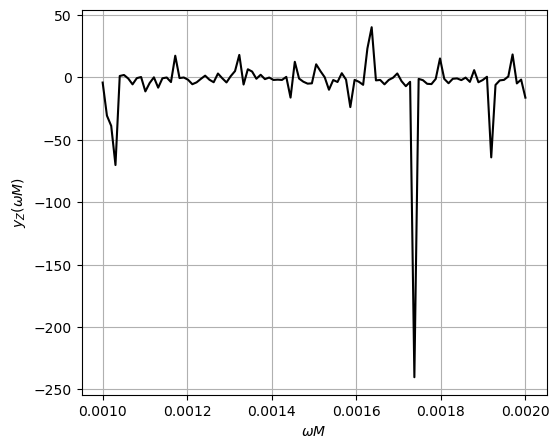

In [46]:


#profile = profiles[0.146]
#activate_profile(profile)

M = bg_tab['m'][-1]
R = profile['R']
C = M / R
print(C)
omegaR_vals = np.linspace(5e-3, 1e-2, 100)
omega_vals = omegaR_vals / R   # since omegaR = omega*R

yZ_vals = []

for omega in tqdm(omega_vals):
    
    ZR, dZR = ZerilliR(omega, R, EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1], bg_tab)

    ratio = dZR / ZR

    yZ = (2*M)/(1 - 2*C) * ratio

    yZ_vals.append(yZ.real)

omegaM_vals = omega_vals * M

plt.figure(figsize=(6,5))
plt.plot(omegaM_vals, yZ_vals, 'k')
plt.xlabel(r'$\omega M$')
plt.ylabel(r'$y_Z(\omega M)$')
plt.grid(True)
plt.show()


In [45]:
ZerilliR(5e-3, R, EvenSolverNumbaZerilli(5e-3, r_tab, bg_tab)[1], bg_tab=bg_tab)

(np.complex128(-2.2168145079248717e-16+0j),
 np.complex128(1.3966373934660722e-15-0j))

0.19999999310819425


100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


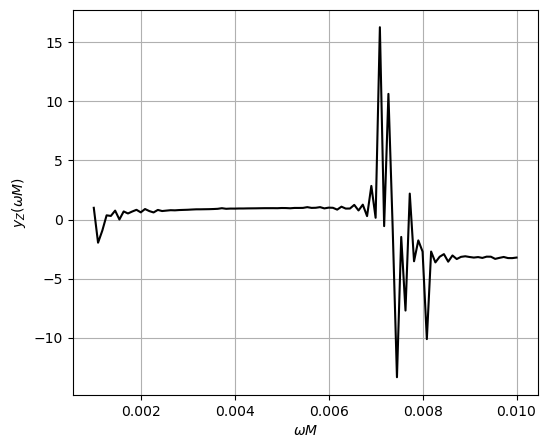

In [50]:


#profile = profiles[0.146]
#activate_profile(profile)

M = bg_tab['m'][-1]
R = profile['R']
C = M / R
print(C)
omegaR_vals = np.linspace(5e-3, 5e-2, 100)
omega_vals = omegaR_vals / R   # since omegaR = omega*R

yZ_vals = []

for omega in tqdm(omega_vals):
    
    ZR, dZR = ZerilliR(omega, R, EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1], bg_tab)

    ratio = dZR / ZR

    yZ = (2*M)/(1 - 2*C) * ratio

    yZ_vals.append(yZ.real)

omegaM_vals = omega_vals * M

plt.figure(figsize=(6,5))
plt.plot(omegaM_vals, yZ_vals, 'k')
plt.xlabel(r'$\omega M$')
plt.ylabel(r'$y_Z(\omega M)$')
plt.grid(True)
plt.show()


0.14000000000041996


100%|██████████| 100/100 [01:32<00:00,  1.08it/s]


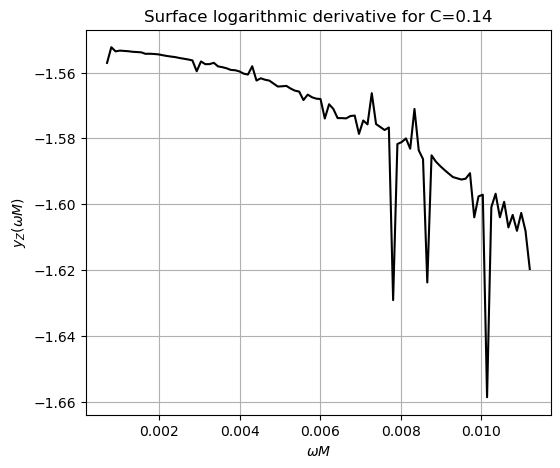

In [54]:


profile = profiles[0.14]
activate_profile(profile)

M = bg_tab['m'][-1]
R = profile['R']
C = M / R
print(C)
omegaR_vals = np.linspace(5e-3, 8e-2, 100)
omega_vals = omegaR_vals / R   # since omegaR = omega*R

yZ_vals = []

for omega in tqdm(omega_vals):
    
    ZR, dZR = ZerilliR(omega, R, EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1], bg_tab)

    ratio = dZR / ZR

    yZ = (2*M)/(1 - 2*C) * ratio

    yZ_vals.append(yZ.real)

omegaM_vals = omega_vals * M

plt.figure(figsize=(6,5))
plt.plot(omegaM_vals, yZ_vals, 'k')
plt.title('Surface logarithmic derivative for C=0.14')
plt.xlabel(r'$\omega M$')
plt.ylabel(r'$y_Z(\omega M)$')
plt.grid(True)
plt.show()

In [52]:
0.01/0.14

0.07142857142857142

# CF helpers

In [8]:

#def initial_coeffs(QR, dQR, R, M, om):
#    fR = 1 - (2*M)/R
#    exp_iomrstar = cm.exp(-1j * om * (R + 2*M * cm.log(R/(2*M) - 1)))#

#    Aout = ((dQR + (1j * om) * QR) / (2 * 1j * om)) * exp_iomrstar
#    Ain  = ((dQR - (1j * om) * QR) / (-2 * 1j * om)) * cm.exp(2j * om * (R + 2*M * cm.log(R/(2*M) - 1)))

#    return Ain, Aout

@njit(nopython=True)
def initial_coeffs(QR, dQR, r, M, om):
    
    f = 1- 2*M/r
    chi_r = (r/(2*M) -1)**(-2j*M*om) * cm.exp(-1j*om*r)

    a0 = QR/chi_r
    a1 = (r/chi_r)*(dQR + (1j*om*r/(r-2*M))*QR)

    return a0, a1

@njit(nopython=True)
def rw_recurrence(n, r, om, M, l=2):
    alpha_n = (1-2*M/r)*(n*(n+1))
    beta_n = -2*(1j*om*r + (1 - 3*M/r)*n)*n
    gamma_n = (1-6*M/r)*n*(n-1) + 6*M/r - l*(l+1)
    delta_n = (2*M/r) *(n-3)*(n+1)

    return alpha_n, beta_n, gamma_n, delta_n

@njit(nopython=True)
def reduce_to_three_term(alpha, beta, gamma, delta, N):
    a = alpha.copy()
    b = beta.copy()
    c = gamma.copy()

    for n in range(2,N):
        factor = delta[n]/c[n-1]
        b[n] = beta[n] - factor * a[n-1]
        c[n] = gamma[n] - factor * b[n-1]
        delta[n] = 0.0
    return a,b,c

@njit(nopython=True)
def continued_fraction(a, b, c, N, tol=1e-10, max_iter=1000):
    cf = b[N]
    for n in reversed(range(N)):
        cf = b[n] - a[n] * c[n+1] / cf
    return cf


"""@njit(nopython=True)
def cf_residual(om, Q, dQ, r, M, l=2, N=500):
    a0, a1 = initial_coeffs(Q, dQ, r, M, om)

    alpha = np.empty(N+2, dtype=np.complex128)
    beta  = np.empty(N+2, dtype=np.complex128)
    gamma = np.empty(N+2, dtype=np.complex128)
    delta = np.empty(N+2, dtype=np.complex128)

    for n in range(N+2):
        an, bn, cn, dn = rw_recurrence(n, r, om, M, l)
        alpha.append(an)
        beta.append(bn)
        gamma.append(cn)
        delta.append(dn)
    
    alpha = np.array(alpha, dtype=np.complex128)
    beta = np.array(beta, dtype=np.complex128)
    gamma = np.array(gamma, dtype=np.complex128)
    delta = np.array(delta, dtype=np.complex128)

    a, b, c = reduce_to_three_term(alpha, beta, gamma, delta, N+2)

    beta[0] += alpha[0] * a1 / a0

    return continued_fraction(a, b, c, N)
"""

@njit(nopython=True)
def cf_residual(om, Q, dQ, r, M, l=2, N=500):
    a0, a1 = initial_coeffs(Q, dQ, r, M, om)

    alpha = np.empty(N+2, dtype=np.complex128)
    beta  = np.empty(N+2, dtype=np.complex128)
    gamma = np.empty(N+2, dtype=np.complex128)
    delta = np.empty(N+2, dtype=np.complex128)

    for n in range(N+2):
        an, bn, cn, dn = rw_recurrence(n, r, om, M, l)
        alpha[n] = an
        beta[n]  = bn
        gamma[n] = cn
        delta[n] = dn

    a, b, c = reduce_to_three_term(alpha, beta, gamma, delta, N+2)

    b[0] = b[0] + alpha[0] * a1 / a0

    return continued_fraction(a, b, c, N)


from scipy.optimize import root
def find_qnm_frequency(initial_guess, R, bg_tab):
    def to_solve(om):
        sol_surface = EvenSolverNumbaZerilli(om, r_tab, bg_tab)[1]
        ZR, dZR = ZerilliR(om, R, sol_surface, bg_tab)
        QR, dQR = Chandrasekhar(om, ZR, dZR, R, bg_tab['m'][-1])
        res = cf_residual(om, QR, dQR, R*1.1, bg_tab['m'][-1])
        return [res.real, res.imag]

    sol = root(to_solve, [initial_guess.real, initial_guess.imag], method='hybr')

    if not sol.success:
        raise RuntimeError(f"Root finding failed: {sol.message}")

    omega_qnm = sol.x[0] + 1j * sol.x[1]
    return omega_qnm






c:\Conda\Lib\site-packages\numba\core\decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [43]:
import numpy as np
from numba import njit

@njit
def initial_coeffs(QR, dQR, r, M, om):
    f = 1.0 - 2.0*M/r

    chi_r = (r/(2.0*M) - 1.0)**(-2j*M*om) * np.exp(-1j*om*r)

    a0 = QR / chi_r
    a1 = (r / chi_r) * (dQR + (1j*om*r/(r - 2.0*M)) * QR)

    return a0, a1

@njit
def rw_recurrence(n, r, om, M, l):
    alpha_n = (1.0 - 2.0*M/r) * (n*(n+1))
    beta_n  = -2.0 * (1j*om*r + (1.0 - 3.0*M/r)*n) * n
    gamma_n = (1.0 - 6.0*M/r)*n*(n-1) + 6.0*M/r - l*(l+1)
    delta_n = (2.0*M/r) * (n-3)*(n+1)

    return alpha_n, beta_n, gamma_n, delta_n

@njit
def reduce_to_three_term(alpha, beta, gamma, delta, N):
    a = alpha.copy()
    b = beta.copy()
    c = gamma.copy()

    for n in range(2, N):
        factor = delta[n] / c[n-1]
        b[n] = beta[n] - factor * a[n-1]
        c[n] = gamma[n] - factor * b[n-1]

    return a, b, c

@njit
def continued_fraction(a, b, c, N):
    cf = b[N]
    for n in range(N-1, -1, -1):
        cf = b[n] - a[n] * c[n+1] / cf
    return cf

@njit
def cf_residual(om, Q, dQ, r, M, l, N):
    # interior ratio
    a0, a1 = initial_coeffs(Q, dQ, r, M, om)
    ratio_int = a1 / a0

    # recurrence coefficients
    alpha = np.empty(N+2, dtype=np.complex128)
    beta  = np.empty(N+2, dtype=np.complex128)
    gamma = np.empty(N+2, dtype=np.complex128)
    delta = np.empty(N+2, dtype=np.complex128)

    for n in range(N+2):
        alpha[n], beta[n], gamma[n], delta[n] = rw_recurrence(n, r, om, M, l)

    # reduce 4-term to 3-term
    a, b, c = reduce_to_three_term(alpha, beta, gamma, delta, N+2)

    # continued fraction for n >= 1
    cf = b[N]
    for n in range(N-1, 1, -1):
        cf = b[n] - a[n]*c[n+1]/cf

    ratio_cf = -c[1] / cf

    return ratio_int - ratio_cf



from scipy.optimize import root

def find_qnm_frequency(initial_guess, R, bg_tab, l=2, N=500):
    M = bg_tab['m'][-1]
    r_match = 1.1 * R

    def to_solve(z):
        om = z[0] + 1j*z[1]

        sol_surface = EvenSolverNumbaZerilli(om, r_tab, bg_tab)[1]
        ZR, dZR = ZerilliR(om, R, sol_surface, bg_tab)
        QR, dQR = Chandrasekhar(om, ZR, dZR, R, M)

        res = cf_residual(om, QR, dQR, r_match, M, l, N)
        return [res.real, res.imag]

    sol = root(to_solve, [initial_guess.real, initial_guess.imag], method='hybr')

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol.x[0] + 1j*sol.x[1]


(-0.9898891442317056+1.993410959473257j)
(-0.9898891442317056+1.993410959473257j)


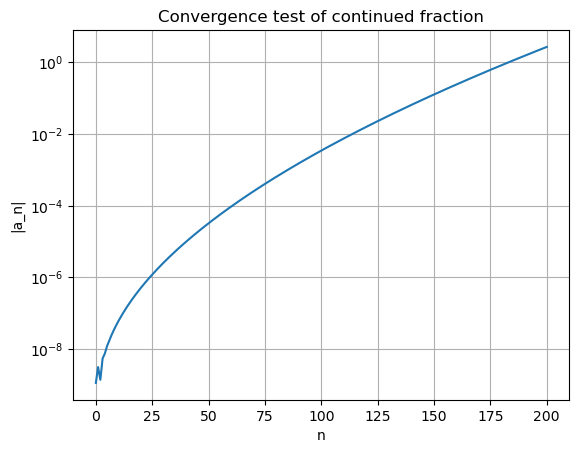

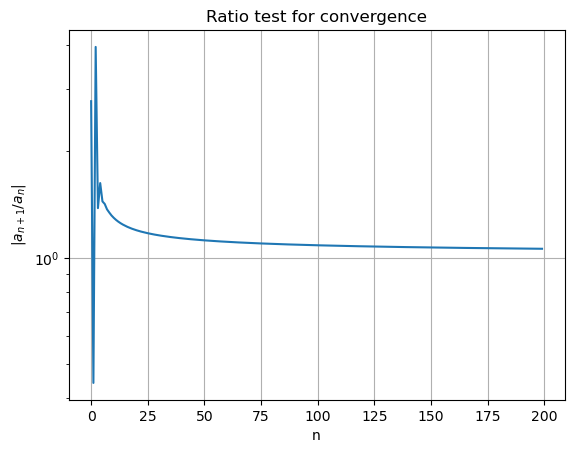

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Use your existing functions:
# initial_coeffs
# rw_recurrence
# reduce_to_three_term
# --------------------------------------------

def compute_an_sequence(om, Q, dQ, r, M, l, Nmax):

    # --- Interior initial coefficients ---
    a0, a1 = initial_coeffs(Q, dQ, r, M, om)

    # --- Build recurrence arrays ---
    alpha = np.empty(Nmax+2, dtype=np.complex128)
    beta  = np.empty(Nmax+2, dtype=np.complex128)
    gamma = np.empty(Nmax+2, dtype=np.complex128)
    delta = np.empty(Nmax+2, dtype=np.complex128)

    for n in range(Nmax+2):
        alpha[n], beta[n], gamma[n], delta[n] = rw_recurrence(n, r, om, M, l)

    # --- Reduce to 3-term recurrence ---
    a3, b3, c3 = reduce_to_three_term(alpha, beta, gamma, delta, Nmax+2)

    # --- Solve recurrence forward ---
    a = np.zeros(Nmax+1, dtype=np.complex128)
    a[0] = a0
    a[1] = a1

    for n in range(1, Nmax):
        # 3-term recurrence:
        # a[n+1] = -(b[n] a[n] + c[n] a[n-1]) / a3[n]
        a[n+1] = -(b3[n] * a[n] + c3[n] * a[n-1]) / a3[n]

    return a


# --------------------------------------------------
# Example usage (replace with your actual inputs)
# --------------------------------------------------

M = bg_tab['m'][-1]
l = 2
r = 1.1
Nmax = 200

# Choose some test omega (complex)
om = 0.4 - 0.2j

# These must come from your interior integration
sol_surface = EvenSolverNumbaZerilli(om, r_tab, bg_tab)[1]
ZR, dZR = ZerilliR(om, r, sol_surface, bg_tab)
QR, dQR = Chandrasekhar(om, ZR, dZR, r, M)
    
a_seq = compute_an_sequence(om, QR, dQR, r, M, l, Nmax)
print(cf_residual(om, QR, dQR, r, M, l, Nmax))
print(cf_residual(om, QR, dQR, r, M, l, Nmax+100))

# --------------------------------------------------
# Plot |a_n|
# --------------------------------------------------

plt.figure()
plt.semilogy(np.abs(a_seq))
plt.xlabel("n")
plt.ylabel("|a_n|")
plt.title("Convergence test of continued fraction")
plt.grid(True)
plt.show()

ratio = np.abs(a_seq[1:] / a_seq[:-1])

plt.figure()
plt.semilogy(ratio)
plt.xlabel("n")
plt.ylabel(r"$|a_{n+1}/a_n|$")
plt.title("Ratio test for convergence")
plt.grid(True)
plt.show()

del sol_surface, ZR, dZR, QR, dQR, a_seq


In [37]:
muller_init(0.7 - 0.3j)

 0 | ω = 0.21671215-0.60049121j | |CF| = 9.559e-01
 1 | ω = 0.03767147-0.55303899j | |CF| = 3.013e-01
 2 | ω = -0.00065620-0.49090742j | |CF| = 1.603e-02
 3 | ω = 0.00000158-0.48700654j | |CF| = 2.415e-05
 4 | ω = 0.00000000-0.48700079j | |CF| = 2.699e-07
 5 | ω = 0.00000000-0.48700085j | |CF| = 2.742e-09
 6 | ω = 0.00000000-0.48700085j | |CF| = 1.062e-09
 7 | ω = 0.00000000-0.48700086j | |CF| = 1.680e-09
 8 | ω = 0.00000000-0.48700086j | |CF| = 7.279e-10
 9 | ω = 0.00000000-0.48700086j | |CF| = 3.324e-10
10 | ω = -0.00000000-0.48700085j | |CF| = 3.104e-10
11 | ω = 0.00000000-0.48700085j | |CF| = 2.111e-11


np.complex128(1.7358479704497079e-12-0.4870008549627846j)

# Testing

In [44]:

from tqdm import tqdm
def scan_cf(Re_range, Im_range, n_re, n_im, R, bg_tab, N=500):
    r_match = 1.01 * R
    Re = np.linspace(*Re_range, n_re)
    Im = np.linspace(*Im_range, n_im)

    grid = np.zeros((n_re, n_im))

    for i, re in enumerate(tqdm(Re)):
        for j, im in enumerate(Im):
            om = re + 1j*im
            sol_surface = EvenSolverNumbaZerilli(om, r_tab, bg_tab)[1]
            ZR, dZR = ZerilliR(om, R, sol_surface, bg_tab)
            QR, dQR = Chandrasekhar(om, ZR, dZR, R, bg_tab['m'][-1])
            res = cf_residual(om, QR, dQR, r_match, bg_tab['m'][-1],l=2, N=N)
            grid[i,j] = np.log10(abs(res) + 1e-30)


    return Re, Im, grid


In [13]:
cf_residual(0.5 - 0.1j, 1.0, 1.0, 15.0, 2.0, 2, 500)

(17.103242339504185+10.07386454373479j)

In [14]:
cf_residual(0.5 - 0.1j, 1.0, 1.0, 15.0, 2.0, 2, 500)

(17.103242339504185+10.07386454373479j)

In [73]:
cf_residual(0.5 - 0.1j, 1.0, 1.0, 15.0, 2.0, 2, 500)

(17.103242339504185+10.07386454373479j)

100%|██████████| 150/150 [2:31:27<00:00, 60.58s/it] 


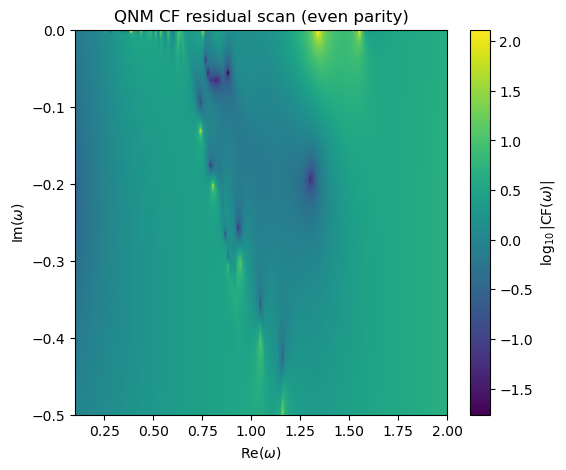

In [100]:
re_test, im_test, grid = scan_cf((0.1, 2), (-0.5,0.0), 150, 150, r_match, bg_tab, N=500)
#150x150
plt.figure(figsize=(6,5))

plt.imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega)$')
plt.ylabel(r'Im$(\omega)$')
plt.title('QNM CF residual scan (even parity)')
plt.show()

100%|██████████| 150/150 [3:26:16<00:00, 82.51s/it]  


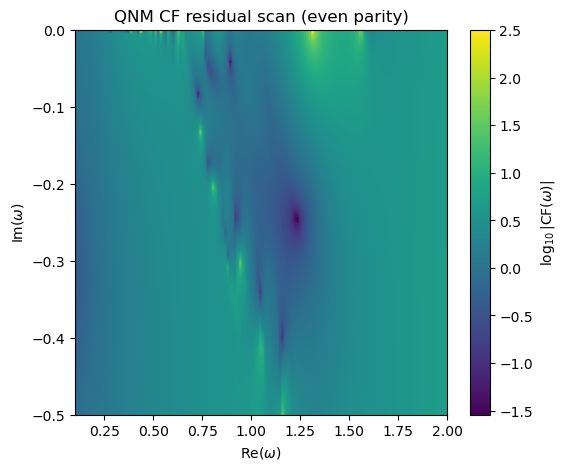

In [34]:
re_test, im_test, grid = scan_cf((0.1, 2), (-0.5,0.0), 150, 150, r_match, bg_tab, N=500)
#150x150
plt.figure(figsize=(6,5))

plt.imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega)$')
plt.ylabel(r'Im$(\omega)$')
plt.title('QNM CF residual scan (even parity)')
plt.show()

In [44]:
0.5/0.2

2.5

100%|██████████| 150/150 [3:11:25<00:00, 76.57s/it]  


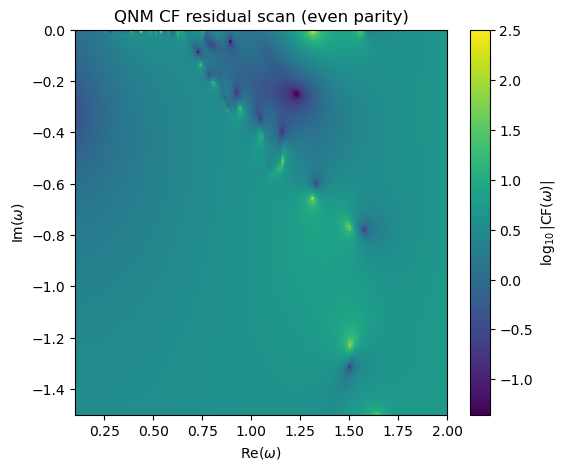

In [ ]:
#Broad scan
re_test, im_test, grid = scan_cf((0.1, 2), (-1.5,0.0), 150, 150, r_match, bg_tab, N=500)

plt.figure(figsize=(6,5))

plt.imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega)$')
plt.ylabel(r'Im$(\omega)$')
plt.title('QNM CF residual scan (even parity)')
plt.show()

In [107]:
3*0.2

0.6000000000000001

In [ ]:
re_test, im_test, grid = scan_cf((0.1, 3), (-2,0.0), 180, 180, r_match, bg_tab, N=500)

plt.figure(figsize=(6,5))


plt.imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega)$')
plt.ylabel(r'Im$(\omega)$')
plt.title('QNM CF residual scan (even parity)')
plt.show()

np.savez("param_scan_Re3_Im2.npz", re_test=re_test, im_test=im_test, grid=grid)

NameError: name 'scan_cf' is not defined

In [ ]:
del re_test, im_test, grid
data = np.load("param_scan_Re3_Im2.npz")
re_test = data['re_test']
im_test = data['im_test']
grid = data['grid']




In [26]:
np.savez("param_scan_Re3_Im2_copy.npz", re_test=re_test, im_test=im_test, grid=grid)

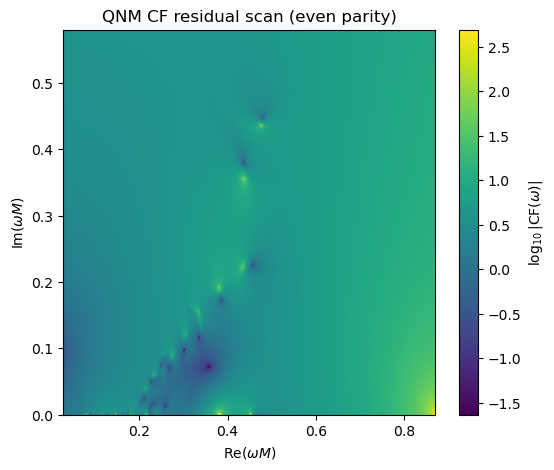

In [25]:
plt.figure(figsize=(6,5))



plt.imshow(
    grid.T[::-1, :], #grid.T,   # transpose so Im is vertical
    extent=[re_test[0]*M, re_test[-1]*M, -im_test[-1]*M, -im_test[0]*M],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega M)$')
plt.ylabel(r'Im$(\omega M)$')
plt.title('QNM CF residual scan (even parity)')
plt.show()

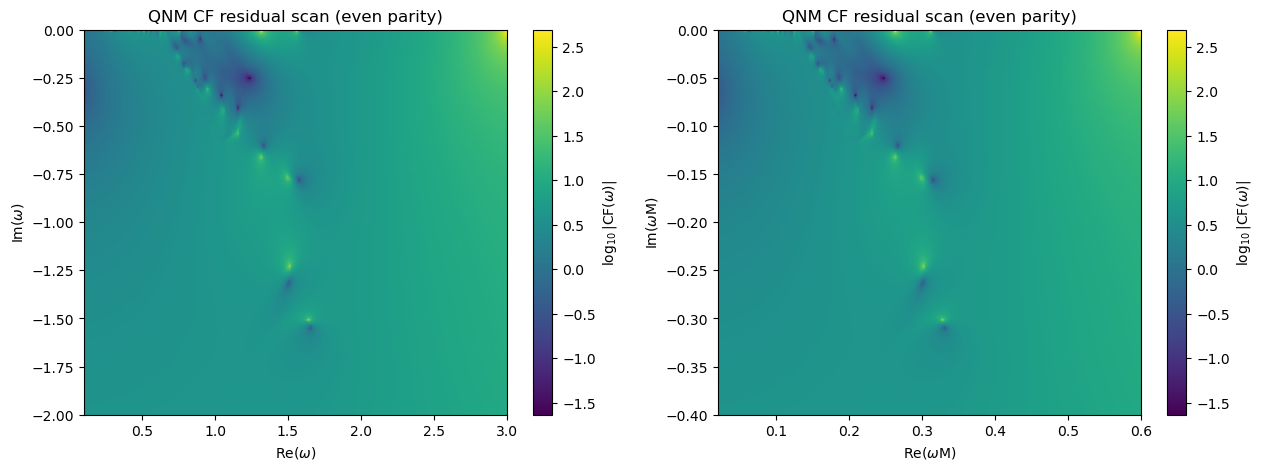

In [113]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
im1 = ax[0].imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

fig.colorbar(im1, ax=ax[0], label=r'$\log_{10} |{\rm CF}(\omega)|$')
ax[0].set_xlabel(r'Re$(\omega $)')
ax[0].set_ylabel(r'Im$(\omega $)')
ax[0].set_title('QNM CF residual scan (even parity)')

im2 = ax[1].imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0]*M, re_test[-1]*M, im_test[0]*M, im_test[-1]*M],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

fig.colorbar(im2, ax=ax[1], label=r'$\log_{10} |{\rm CF}(\omega)|$')
ax[1].set_xlabel(r'Re$(\omega $M)')
ax[1].set_ylabel(r'Im$(\omega $M)')
ax[1].set_title('QNM CF residual scan (even parity)')
plt.show()

In [98]:
re_test, im_test, grid = scan_cf((0.1, 2), (-0.5,0.0), 70, 70, r_match, bg_tab, N=500)

100%|██████████| 70/70 [42:07<00:00, 36.10s/it] 


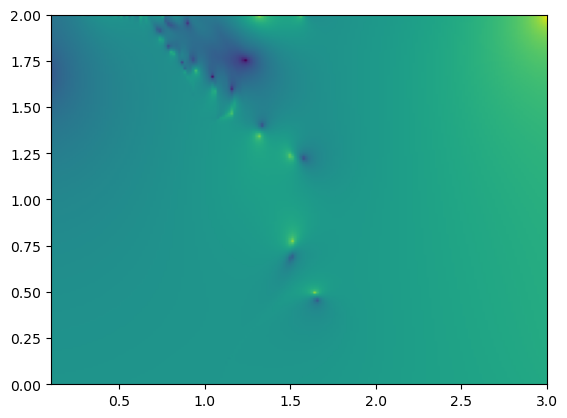

In [22]:
im_plot = -im_test

plt.imshow(
    grid.T,
    extent=[re_test[0], re_test[-1], im_plot[-1], im_plot[0]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

In [ ]:
re_test_sm5, im_test_sm5, grid_sm5 = scan_cf((0.5, 1.5), (-0.75,0.0), 70, 70, r_match, bg_tab, N=500)
re_test_sm8, im_test_sm8, grid_sm8 = scan_cf((0.5, 1.5), (-0.75,0.0), 70, 70, r_match, bg_tab, N=800)
re_test_sm12, im_test_sm12, grid_sm12 = scan_cf((0.5, 1.5), (-0.75,0.0), 70, 70, r_match, bg_tab, N=1200)



100%|██████████| 70/70 [35:53<00:00, 30.76s/it]


In [100]:
del re_test_sm5, im_test_sm5, grid_sm5, re_test_sm8, im_test_sm8, grid_sm8, re_test_sm12, im_test_sm12, grid_sm12

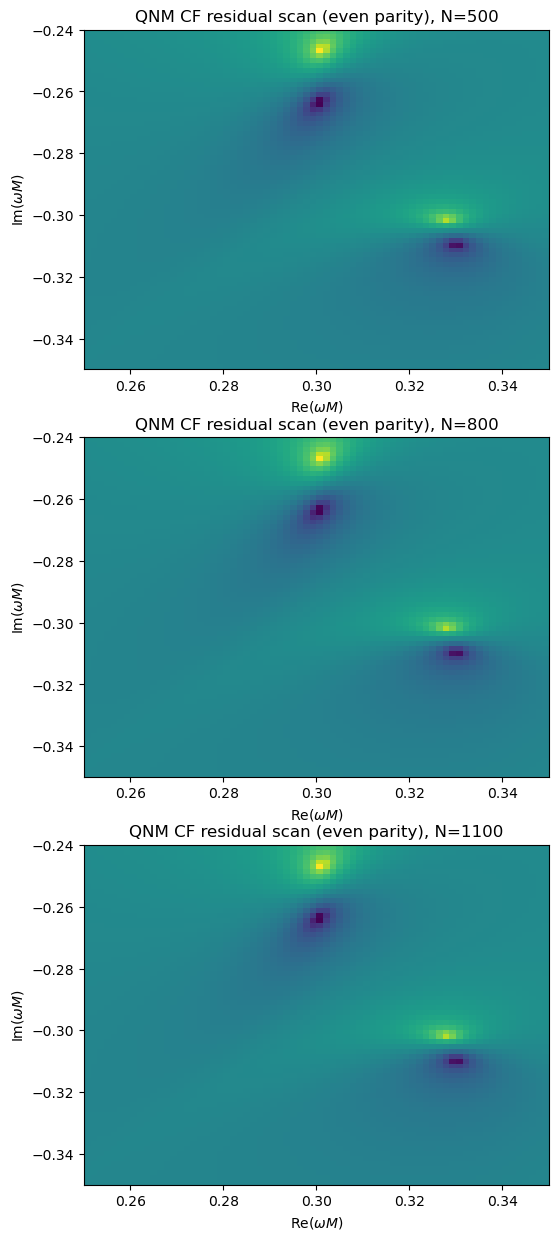

In [75]:
# 70x70 grid
fig, ax = plt.subplots(3, figsize=(6,15))

ax[0].imshow(
    grid_sm5.T,   # transpose so Im is vertical
    extent=[re_test_sm5[0]*M, re_test_sm5[-1]*M, im_test_sm5[0]*M, im_test_sm5[-1]*M],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

ax[1].imshow(
    grid_sm8.T,   # transpose so Im is vertical
    extent=[re_test_sm8[0]*M, re_test_sm8[-1]*M, im_test_sm8[0]*M, im_test_sm8[-1]*M],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

ax[2].imshow(
    grid_sm12.T,   # transpose so Im is vertical
    extent=[re_test_sm12[0]*M, re_test_sm12[-1]*M, im_test_sm12[0]*M, im_test_sm12[-1]*M],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

for i in range(3):
    ax[i].set_xlabel(r'Re$(\omega M)$')
    ax[i].set_ylabel(r'Im$(\omega M)$')
    ax[i].set_title(f'QNM CF residual scan (even parity), N={500 + i*300}')
    
    
    
plt.show()

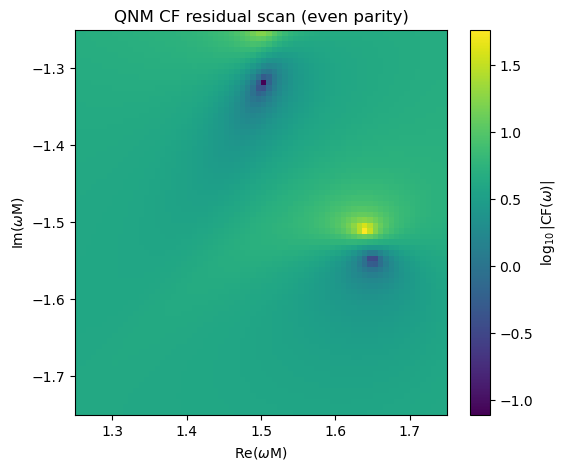

In [77]:
# 70x70 grid
plt.figure(figsize=(6,5))

plt.imshow(
    grid_sm.T,   # transpose so Im is vertical
    extent=[re_test_sm[0], re_test_sm[-1], im_test_sm[0], im_test_sm[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega$M)')
plt.ylabel(r'Im$(\omega$M)')
plt.title('QNM CF residual scan (even parity)')
plt.show()

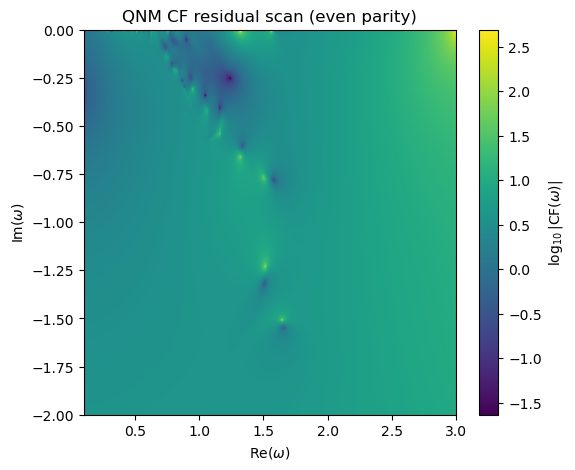

In [46]:
# 70x70 grid
plt.figure(figsize=(6,5))

plt.imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega)$')
plt.ylabel(r'Im$(\omega)$')
plt.title('QNM CF residual scan (even parity)')
plt.show()

In [106]:
3*0.2

0.6000000000000001

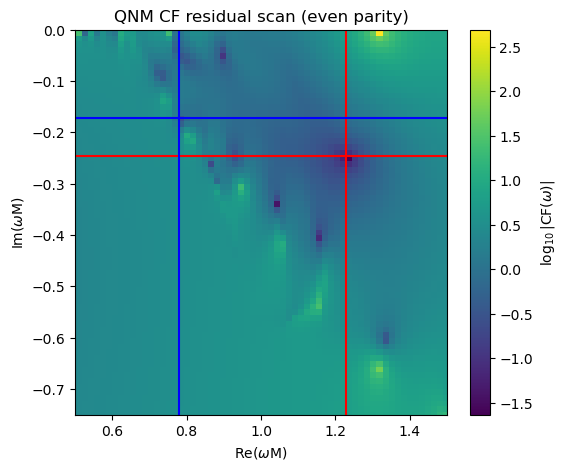

In [121]:
plt.figure(figsize=(6,5))

plt.imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)
plt.xlim(0.5, 1.5)
plt.ylim(-0.75, 0)
plt.axhline(-0.24531493, color='red')
plt.axvline(1.22918595, color='red')
plt.axhline(-0.17216419, color='blue')
plt.axvline(0.78079428, color='blue')
plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega$M)')
plt.ylabel(r'Im$(\omega$M)')
plt.title('QNM CF residual scan (even parity)')
plt.show()

In [ ]:
0.78079428-0.17216419j, 1.22918595-0.24531493j

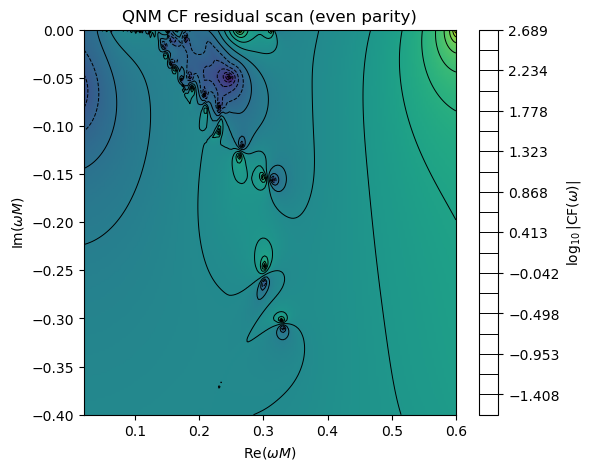

In [58]:
plt.figure(figsize=(6,5))

plt.imshow(
    grid.T,
    extent=[re_test[0]*M, re_test[-1]*M, im_test[0]*M, im_test[-1]*M],
    origin='lower',
    aspect='auto',
    cmap='viridis',
    vmin=-1.5,
    vmax=3.0
)

levels = np.linspace(grid.min(), grid.max(), 20)  #[-1.4, -1.3, -1.2, -1.1, -1.0]

plt.contour(
    re_test * M,
    im_test * M,
    grid.T,
    levels=levels,
    colors='black',
    linewidths=0.7
)

plt.colorbar(label=r'$\log_{10}|{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega M)$')
plt.ylabel(r'Im$(\omega M)$')
plt.title('QNM CF residual scan (even parity)')
plt.show()


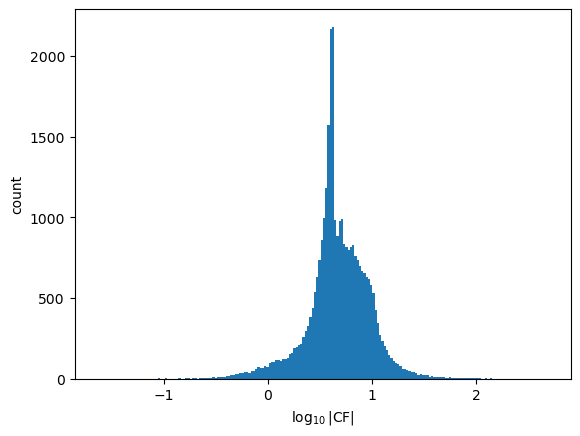

In [59]:
plt.hist(grid.flatten(), bins=200)
plt.xlabel(r'$\log_{10}|{\rm CF}|$')
plt.ylabel('count')
plt.show()


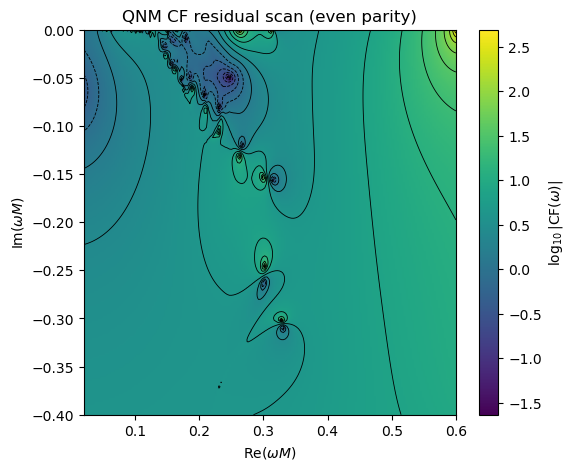

In [65]:
fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(
    grid.T,
    extent=[re_test[0]*M, re_test[-1]*M, im_test[0]*M, im_test[-1]*M],
    origin='lower',
    aspect='auto',
    cmap='viridis',
    vmin=grid.min(),
    vmax=grid.max()
)

levels = np.linspace(grid.min(), grid.max(), 20)

ax.contour(
    re_test * M,
    im_test * M,
    grid.T,
    levels=levels,
    colors='black',
    linewidths=0.6
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\log_{10}|{\rm CF}(\omega)|$')
ax.set_xlabel(r'Re$(\omega M)$')
ax.set_ylabel(r'Im$(\omega M)$')
ax.set_title('QNM CF residual scan (even parity)')
plt.show()


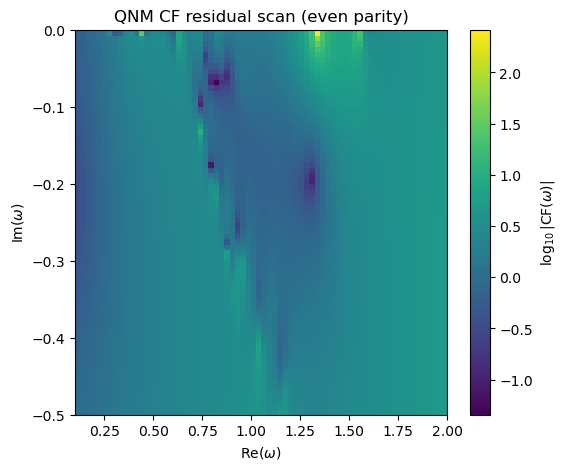

In [ ]:
# 70x70 grid
plt.figure(figsize=(6,5))

plt.imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega)$')
plt.ylabel(r'Im$(\omega)$')
plt.title('QNM CF residual scan (even parity)')
plt.show()

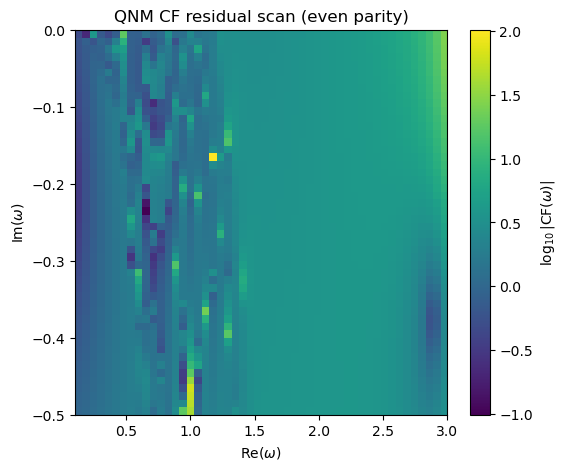

In [75]:
plt.figure(figsize=(6,5))

plt.imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega)$')
plt.ylabel(r'Im$(\omega)$')
plt.title('QNM CF residual scan (even parity)')
plt.show()

In [81]:
R

np.float64(0.9999999999999999)

In [ ]:
N_box = [300, 400, 500, 600]
r_match_box = [1.05*R, 1.1*R, 1.2*R, 1.3*R]

for N in N_box:
    for r_match in r_match_box:
        re_test, im_test, grid = scan_cf((0.1,2.5), (-0.5 , 0.0), 50, 50, r_match, bg_tab, N=N)
        plt.figure(figsize=(6,5))

        plt.imshow(
            grid.T,   # transpose so Im is vertical
            extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
            origin='lower',
            aspect='auto',
            cmap='viridis'
        )
        plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
        plt.xlabel(r'Re$(\omega)$')
        plt.ylabel(r'Im$(\omega)$')
        plt.title('QNM CF residual scan (even parity), N={}, r_match={:.2f}R'.format(N, r_match/R))
        plt.show()

        




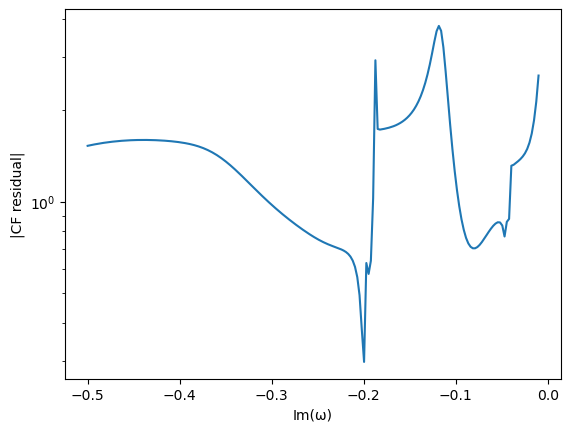

In [83]:
re_fixed = 0.8
im_vals = np.linspace(-0.5, -0.01, 200)
res_vals = []

for im in im_vals:
    om = re_fixed + 1j*im
    sol_surface = EvenSolverNumbaZerilli(om, r_tab, bg_tab)[1]
    ZR, dZR = ZerilliR(om, R, sol_surface, bg_tab)
    QR, dQR = Chandrasekhar(om, ZR, dZR, R, bg_tab['m'][-1])
    res = cf_residual(om, QR, dQR, r_match, bg_tab['m'][-1], 2, 500)
    res_vals.append(abs(res))

plt.semilogy(im_vals, res_vals)
plt.xlabel('Im(ω)')
plt.ylabel('|CF residual|')
plt.show()


# QNM finding

In [45]:
def CF(omega, N=800):
    sol_surface = EvenSolverNumbaZerilli(omega, r_tab, bg_tab)[1]
    ZR, dZR = ZerilliR(omega, R, sol_surface, bg_tab)
    QR, dQR = Chandrasekhar(omega, ZR, dZR, R, bg_tab['m'][-1])
    return cf_residual(
        omega, QR, dQR, 1.1*R, bg_tab['m'][-1], l=2, N=N
    )

def find_qnm_muller(
    w0, w1, w2,
    tol=1e-8,
    max_iter=50,
    N=800,
    verbose=True
):
    f0, f1, f2 = CF(w0, N=N), CF(w1, N=N), CF(w2, N=N)

    for k in range(max_iter):
        h1 = w1 - w0
        h2 = w2 - w1

        δ1 = (f1 - f0) / h1
        δ2 = (f2 - f1) / h2

        d = (δ2 - δ1) / (h2 + h1)

        b = δ2 + h2 * d
        D = np.sqrt(b*b - 4*f2*d)

        # Choose denominator to avoid cancellation
        if abs(b + D) > abs(b - D):
            denom = b + D
        else:
            denom = b - D

        if denom == 0:
            raise RuntimeError("Müller breakdown")
        if not np.isfinite(denom) or abs(denom) < 1e-14:
            raise RuntimeError("Müller breakdown: degenerate quadratic")

        w3 = w2 - 2*f2 / denom
        f3 = CF(w3, N=N)

        if verbose:
            print(f"{k:2d} | ω = {w3:.8f} | |CF| = {abs(f3):.3e}")

        if abs(f3) < tol:
            return w3
        if abs(w3 - w2) < 1e-12:
            return w3


        w0, w1, w2 = w1, w2, w3
        f0, f1, f2 = f1, f2, f3

    raise RuntimeError("Müller did not converge")

"""def muller_init(om_guess, delta=0.05-0.05j, tol = 1e-10, max_iter=100):
    w0 = om_guess - delta
    w1 = om_guess
    w2 = om_guess + delta
    return find_qnm_muller(w0, w1, w2, tol=tol, max_iter=max_iter)"""

def muller_init(
    om_guess,
    delta=0.05,
    tol=1e-10,
    max_iter=150,
    N=800
):
    w0 = om_guess - delta*(1 + 0.3j)
    w1 = om_guess
    w2 = om_guess + delta*(0.7 - 0.2j)

    return find_qnm_muller(w0, w1, w2, tol=tol, max_iter=max_iter)



In [80]:
om1guess = 1.45 - 1.3j
om2guess = 1.5 - 1.35j
om3guess = 1.55 - 1.4j

omega_qnm_muller = find_qnm_muller(om1guess, om2guess, om3guess, tol=1e-10, max_iter=100)

 0 | ω = 1.50997431-1.32089437j | |CF| = 7.234e-01
 1 | ω = 1.49810393-1.30729135j | |CF| = 8.785e-01
 2 | ω = 1.50372082-1.31496258j | |CF| = 9.361e-02
 3 | ω = 1.50273225-1.31546376j | |CF| = 4.074e-02
 4 | ω = 1.50286908-1.31614853j | |CF| = 2.689e-02
 5 | ω = 1.50255876-1.31594741j | |CF| = 1.410e-02
 6 | ω = 1.50259744-1.31611156j | |CF| = 5.639e-03
 7 | ω = 1.50251067-1.31617317j | |CF| = 1.962e-03
 8 | ω = 1.50254569-1.31618079j | |CF| = 1.418e-03
 9 | ω = 1.50252916-1.31618402j | |CF| = 3.140e-04
10 | ω = 1.50252763-1.31618795j | |CF| = 1.057e-04
11 | ω = 1.50252551-1.31618932j | |CF| = 7.510e-05
12 | ω = 1.50252667-1.31618934j | |CF| = 2.325e-05
13 | ω = 1.50252638-1.31618944j | |CF| = 4.627e-06
14 | ω = 1.50252638-1.31618950j | |CF| = 2.138e-06
15 | ω = 1.50252634-1.31618950j | |CF| = 1.663e-06
16 | ω = 1.50252636-1.31618951j | |CF| = 6.663e-07
17 | ω = 1.50252635-1.31618951j | |CF| = 2.819e-07
18 | ω = 1.50252636-1.31618952j | |CF| = 3.676e-07
19 | ω = 1.50252635-1.31618952j

In [46]:
om_guess = 1.5 - 1.35j

omega_qnm_muller = muller_init(om_guess)

 0 | ω = 1.55823045-1.37738478j | |CF| = 5.565e-01
 1 | ω = 1.56659130-1.37115795j | |CF| = 2.162e-01
 2 | ω = 1.56702587-1.36633867j | |CF| = 5.930e-02
 3 | ω = 1.56849574-1.36603172j | |CF| = 2.198e-02
 4 | ω = 1.56812855-1.36572832j | |CF| = 5.610e-03
 5 | ω = 1.56823815-1.36568390j | |CF| = 1.190e-03
 6 | ω = 1.56823450-1.36565556j | |CF| = 2.776e-04
 7 | ω = 1.56824111-1.36565675j | |CF| = 9.353e-05
 8 | ω = 1.56823996-1.36565520j | |CF| = 1.909e-05
 9 | ω = 1.56824031-1.36565499j | |CF| = 3.958e-06
10 | ω = 1.56824029-1.36565489j | |CF| = 1.164e-06
11 | ω = 1.56824032-1.36565490j | |CF| = 3.308e-07
12 | ω = 1.56824031-1.36565490j | |CF| = 6.312e-08
13 | ω = 1.56824031-1.36565490j | |CF| = 1.304e-08
14 | ω = 1.56824031-1.36565490j | |CF| = 4.289e-09
15 | ω = 1.56824031-1.36565490j | |CF| = 9.719e-10
16 | ω = 1.56824031-1.36565490j | |CF| = 2.139e-10
17 | ω = 1.56824031-1.36565490j | |CF| = 6.018e-11


In [47]:
om_guess = 1.25 - 0.2j

omega_qnm_muller = muller_init(om_guess)

 0 | ω = 1.21659769-0.15848412j | |CF| = 1.894e-01
 1 | ω = 1.21127758-0.18791932j | |CF| = 1.581e-01
 2 | ω = 1.19525781-0.16753407j | |CF| = 2.279e-01
 3 | ω = 1.20079732-0.19236258j | |CF| = 1.660e-01
 4 | ω = 1.18446306-0.18181995j | |CF| = 2.065e-01
 5 | ω = 1.17977371-0.16007640j | |CF| = 3.025e-01
 6 | ω = 1.15411522-0.17343085j | |CF| = 2.930e-01
 7 | ω = 1.15573373-0.14712717j | |CF| = 4.420e-01
 8 | ω = 1.13666578-0.17073020j | |CF| = 3.178e-01
 9 | ω = 1.12739754-0.14538398j | |CF| = 5.068e-01
10 | ω = 1.12359330-0.17991651j | |CF| = 2.520e-01
11 | ω = 1.09558628-0.17880353j | |CF| = 2.581e-01
12 | ω = 1.06825388-0.14885025j | |CF| = 4.799e-01
13 | ω = 1.08197655-0.22646825j | |CF| = 2.369e-01
14 | ω = 1.11320038-0.21365873j | |CF| = 6.964e-02
15 | ω = 1.12104658-0.22392007j | |CF| = 4.421e-02
16 | ω = 1.12896931-0.21364579j | |CF| = 4.704e-02
17 | ω = 1.12844518-0.22209627j | |CF| = 1.872e-02
18 | ω = 1.13280055-0.22115449j | |CF| = 9.747e-03
19 | ω = 1.13233644-0.22671539j

In [92]:
om_guess = 1.5 - 1.35j

omega_qnm_muller = muller_init(om_guess)

 0 | ω = 1.48918873-1.31974581j | |CF| = 1.004e+00
 1 | ω = 1.50195126-1.32221449j | |CF| = 3.351e-01
 2 | ω = 1.50122467-1.31800605j | |CF| = 1.131e-01
 3 | ω = 1.50288115-1.31672915j | |CF| = 5.297e-02
 4 | ω = 1.50200033-1.31636572j | |CF| = 3.924e-02
 5 | ω = 1.50244555-1.31637029j | |CF| = 1.013e-02
 6 | ω = 1.50248409-1.31624386j | |CF| = 3.575e-03
 7 | ω = 1.50256268-1.31618966j | |CF| = 2.969e-03
 8 | ω = 1.50251624-1.31619616j | |CF| = 7.371e-04
 9 | ω = 1.50252566-1.31619170j | |CF| = 1.210e-04
10 | ω = 1.50252552-1.31618994j | |CF| = 6.068e-05
11 | ω = 1.50252646-1.31619010j | |CF| = 4.071e-05
12 | ω = 1.50252613-1.31618976j | |CF| = 1.722e-05
13 | ω = 1.50252635-1.31618964j | |CF| = 7.659e-06
14 | ω = 1.50252624-1.31618952j | |CF| = 8.644e-06
15 | ω = 1.50252633-1.31618957j | |CF| = 2.566e-06
16 | ω = 1.50252634-1.31618953j | |CF| = 7.474e-07
17 | ω = 1.50252635-1.31618952j | |CF| = 2.127e-07
18 | ω = 1.50252635-1.31618952j | |CF| = 5.870e-08
19 | ω = 1.50252635-1.31618952j

In [ ]:
om_guess = 1.25 - 0.2j

omega_qnm_muller = muller_init(om_guess)

 0 | ω = 1.02885527-0.13982231j | |CF| = 8.734e-01
 1 | ω = 1.09910851-0.29444975j | |CF| = 2.680e-01
 2 | ω = 1.11664200-0.33394437j | |CF| = 1.854e-01
 3 | ω = 1.11591088-0.31690542j | |CF| = 7.252e-02
 4 | ω = 1.10979805-0.31353221j | |CF| = 7.608e-02
 5 | ω = 1.11329474-0.31426374j | |CF| = 2.653e-02
 6 | ω = 1.11284805-0.31289117j | |CF| = 1.514e-02
 7 | ω = 1.11208048-0.31233246j | |CF| = 1.510e-02
 8 | ω = 1.11274602-0.31203993j | |CF| = 9.829e-03
 9 | ω = 1.11237620-0.31192298j | |CF| = 7.384e-03
10 | ω = 1.11271560-0.31165700j | |CF| = 8.436e-03
11 | ω = 1.11238018-0.31169929j | |CF| = 5.425e-03
12 | ω = 1.11251648-0.31148497j | |CF| = 4.698e-03
13 | ω = 1.11225016-0.31155952j | |CF| = 5.532e-03
14 | ω = 1.11238755-0.31142121j | |CF| = 3.164e-03
15 | ω = 1.11256059-0.31127660j | |CF| = 5.315e-03
16 | ω = 1.11230638-0.31128881j | |CF| = 2.378e-03
17 | ω = 1.11238907-0.31122552j | |CF| = 2.014e-03
18 | ω = 1.11227955-0.31118564j | |CF| = 1.807e-03
19 | ω = 1.11235845-0.31116735j

In [15]:
omega_qnm_muller

np.complex128(1.112298305021555-0.3110111966950874j)

In [95]:
om_guess = 1.65 - 1.55j

omega_qnm_muller2 = muller_init(om_guess)

 0 | ω = 1.65289807-1.54786331j | |CF| = 1.190e-01
 1 | ω = 1.65211076-1.54896468j | |CF| = 1.253e-02
 2 | ω = 1.65220674-1.54887681j | |CF| = 7.749e-04
 3 | ω = 1.65221412-1.54887259j | |CF| = 4.409e-05
 4 | ω = 1.65221458-1.54887234j | |CF| = 1.626e-07
 5 | ω = 1.65221458-1.54887234j | |CF| = 2.686e-08
 6 | ω = 1.65221458-1.54887234j | |CF| = 2.039e-09
 7 | ω = 1.65221458-1.54887234j | |CF| = 2.373e-10
 8 | ω = 1.65221458-1.54887234j | |CF| = 5.744e-11


In [96]:
print(omega_qnm_muller*M, omega_qnm_muller2*M)

(0.300505270234354-0.2632379038473923j) (0.3304429153430415-0.3097744685205928j)


In [ ]:
om_guess = 1.2 - 0.2j
for N in [500, 800, 1200]:
    print(f"N={N}")
    print("QNM freq:", muller_init(om_guess, tol=1e-10, max_iter=100, N=N))


 0 | ω = 1.21265950-0.28236738j | |CF| = 2.500e-01
 1 | ω = 1.22620934-0.25774338j | |CF| = 9.373e-02
 2 | ω = 1.22978801-0.24582355j | |CF| = 4.652e-03
 3 | ω = 1.22942196-0.24535177j | |CF| = 1.226e-03
 4 | ω = 1.22923458-0.24536908j | |CF| = 4.557e-04
 5 | ω = 1.22921084-0.24528092j | |CF| = 3.146e-04
 6 | ω = 1.22920064-0.24532050j | |CF| = 8.197e-05
 7 | ω = 1.22919014-0.24531515j | |CF| = 2.175e-05
 8 | ω = 1.22918560-0.24531505j | |CF| = 2.245e-06
 9 | ω = 1.22918600-0.24531489j | |CF| = 4.375e-07
10 | ω = 1.22918595-0.24531493j | |CF| = 7.028e-08
11 | ω = 1.22918595-0.24531493j | |CF| = 1.230e-09
12 | ω = 1.22918595-0.24531493j | |CF| = 2.767e-10
13 | ω = 1.22918595-0.24531493j | |CF| = 7.457e-11


In [117]:
(0.78079428-0.17216419j )*M

np.complex128(0.15615885599980364-0.0344328379999567j)

In [119]:
(1.22918595-0.24531493j)*M

np.complex128(0.24583718999969087-0.0490629859999383j)

In [48]:
muller_init(0.78079428-0.17216419j)

 0 | ω = 0.81718849-0.18667133j | |CF| = 7.382e-01
 1 | ω = 0.82498529-0.18327186j | |CF| = 5.374e-01
 2 | ω = 0.82359195-0.18688901j | |CF| = 2.616e-01
 3 | ω = 0.82694044-0.18935182j | |CF| = 2.951e-01
 4 | ω = 0.82389727-0.18916094j | |CF| = 1.626e-01
 5 | ω = 0.82499795-0.18983620j | |CF| = 7.011e-02
 6 | ω = 0.82513174-0.19050013j | |CF| = 3.059e-02
 7 | ω = 0.82557934-0.19055674j | |CF| = 4.698e-02
 8 | ω = 0.82527504-0.19067832j | |CF| = 1.512e-02
 9 | ω = 0.82537699-0.19077097j | |CF| = 9.189e-03
10 | ω = 0.82546347-0.19092736j | |CF| = 9.077e-03
11 | ω = 0.82529512-0.19088859j | |CF| = 1.199e-02
12 | ω = 0.82538107-0.19087288j | |CF| = 1.248e-03
13 | ω = 0.82537962-0.19088379j | |CF| = 6.813e-04
14 | ω = 0.82538809-0.19088523j | |CF| = 7.159e-04
15 | ω = 0.82538316-0.19088691j | |CF| = 3.157e-04
16 | ω = 0.82538518-0.19088874j | |CF| = 1.653e-04
17 | ω = 0.82538699-0.19089061j | |CF| = 2.032e-04
18 | ω = 0.82538430-0.19089068j | |CF| = 1.648e-04
19 | ω = 0.82538539-0.19089053j

np.complex128(0.8253856622220639-0.19089110772283563j)

In [50]:
M

array(0.2)

In [49]:
(0.8253856622220639-0.19089110772283563j)*M

np.complex128(0.16507713244456185-0.038178221544601605j)

In [129]:
om_guess = 1.2 - 0.2j
for N in [500, 800, 1200]:
    print(f"N={N}")
    print("QNM freq:", muller_init(om_guess, tol=1e-10, max_iter=100, N=N))

N=500
 0 | ω = 1.21265950-0.28236738j | |CF| = 2.500e-01
 1 | ω = 1.22620934-0.25774338j | |CF| = 9.373e-02
 2 | ω = 1.22978801-0.24582355j | |CF| = 4.652e-03
 3 | ω = 1.22942196-0.24535177j | |CF| = 1.226e-03
 4 | ω = 1.22923458-0.24536908j | |CF| = 4.557e-04
 5 | ω = 1.22921084-0.24528092j | |CF| = 3.146e-04
 6 | ω = 1.22920064-0.24532050j | |CF| = 8.197e-05
 7 | ω = 1.22919014-0.24531515j | |CF| = 2.175e-05
 8 | ω = 1.22918560-0.24531505j | |CF| = 2.245e-06
 9 | ω = 1.22918600-0.24531489j | |CF| = 4.375e-07
10 | ω = 1.22918595-0.24531493j | |CF| = 7.028e-08
11 | ω = 1.22918595-0.24531493j | |CF| = 1.230e-09
12 | ω = 1.22918595-0.24531493j | |CF| = 2.767e-10
13 | ω = 1.22918595-0.24531493j | |CF| = 7.457e-11
QNM freq: (1.2291859535843153-0.24531492701572746j)
N=800
 0 | ω = 1.21265950-0.28236738j | |CF| = 2.500e-01
 1 | ω = 1.22620934-0.25774338j | |CF| = 9.373e-02
 2 | ω = 1.22978801-0.24582355j | |CF| = 4.652e-03
 3 | ω = 1.22942196-0.24535177j | |CF| = 1.226e-03
 4 | ω = 1.2292345

100%|██████████| 70/70 [34:32<00:00, 29.61s/it]


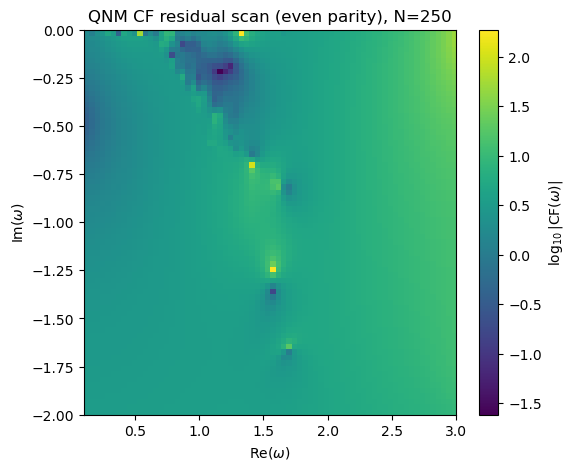

In [55]:
r_match = 1.01*bg_tab['r'][-1]
re, im, grid = scan_cf((0.1, 3), (-2, 0.0), 70, 70, r_match, bg_tab, N=250)

plt.figure(figsize=(6,5))
plt.imshow(
    grid.T,   # transpose so Im is vertical
    extent=[re[0], re[-1], im[0], im[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
plt.xlabel(r'Re$(\omega)$')
plt.ylabel(r'Im$(\omega)$')
plt.title('QNM CF residual scan (even parity), N=250')
plt.show()

# Compactness sweep 

In [135]:
profiles[0.2]["R"]

np.float64(0.9999999999999999)

In [77]:
def activate_profile(profile):

    bg = make_bg_splines(profile)
    global R, M, r_tab, bg_tab
    r_end = profile["r"][-1]
    eps  = profile["r"][0]
    
    R     = profile["R"]
    M     = np.round(profile["M"], 2)
    r_tab = np.linspace(eps, r_end, 4000) #profile["r_tab"]
    bg_tab = make_bg_tables(bg, r_tab)



def find_qnm_vs_compactness(
    omega_guess,
    profiles,
    compactness_list=None,
    tol=1e-10,
    max_iter=100,
    N=800,
    verbose=True
):


    if compactness_list is None:
        compactness_list = sorted(profiles.keys())

    results = {}

    for C in compactness_list:
        if verbose:
            print(f"\n=== Compactness C = {C:.3f} ===")

        try:
            activate_profile(profiles[C])

            omega_qnm = muller_init(
                omega_guess,
                tol=tol,
                max_iter=max_iter,
                N=N
            )

            results[C] = omega_qnm
            omega_guess = omega_qnm  # update guess for next C

            if verbose:
                print(f"QNM @ C={C:.3f}: ω = {omega_qnm}")

        except Exception as e:
            results[C] = np.nan
            if verbose:
                print(f"FAILED at C={C:.3f}: {e}")

    return results


In [139]:
om_guess = 1.2 - 0.2j

results = find_qnm_vs_compactness(
    omega_guess,
    profiles,
    compactness_list=np.linspace(0.1, 0.29, 20),
    tol=1e-10
)


=== Compactness C = 0.100 ===
 0 | ω = 1.46624503-1.18146671j | |CF| = 7.205e+00
 1 | ω = 1.44543133-1.24795384j | |CF| = 2.372e+00
 2 | ω = 1.44110274-1.22674773j | |CF| = 5.358e-01
 3 | ω = 1.44475625-1.22412013j | |CF| = 2.066e-01
 4 | ω = 1.44756942-1.22345854j | |CF| = 1.097e-01
 5 | ω = 1.44666854-1.22252157j | |CF| = 7.417e-02
 6 | ω = 1.44707827-1.22286523j | |CF| = 1.320e-02
 7 | ω = 1.44714138-1.22279201j | |CF| = 6.609e-03
 8 | ω = 1.44724167-1.22281216j | |CF| = 7.135e-03
 9 | ω = 1.44719552-1.22277446j | |CF| = 2.273e-03
10 | ω = 1.44721454-1.22277138j | |CF| = 8.185e-04
11 | ω = 1.44722206-1.22276655j | |CF| = 1.564e-04
12 | ω = 1.44722413-1.22276579j | |CF| = 5.668e-05
13 | ω = 1.44722363-1.22276523j | |CF| = 4.831e-05
14 | ω = 1.44722385-1.22276550j | |CF| = 3.268e-06
15 | ω = 1.44722386-1.22276548j | |CF| = 1.608e-06
16 | ω = 1.44722388-1.22276548j | |CF| = 1.016e-06
17 | ω = 1.44722388-1.22276547j | |CF| = 5.898e-07
18 | ω = 1.44722388-1.22276547j | |CF| = 2.232e-07


C:\Users\Arun KG\AppData\Local\Temp\ipykernel_19484\3041835525.py:23: RuntimeWarning: invalid value encountered in scalar divide
  δ2 = (f2 - f1) / h2


 0 | ω = 1.45631595-1.19273960j | |CF| = 2.926e+01
 1 | ω = 1.44549331-1.36852799j | |CF| = 5.023e+00
 2 | ω = 1.40224004-1.36804423j | |CF| = 4.698e+00
 3 | ω = 1.35225525-1.34297694j | |CF| = 4.802e+00
 4 | ω = 1.39915052-1.20867155j | |CF| = 9.827e+00
 5 | ω = 1.24875382-1.30557467j | |CF| = 5.503e+00
 6 | ω = 1.13069180-1.18350908j | |CF| = 5.439e+00
 7 | ω = 1.02787934-0.99938917j | |CF| = 5.525e+00
 8 | ω = 0.11321236-0.89851885j | |CF| = 2.315e+00
 9 | ω = 0.02202549-0.56370278j | |CF| = 9.392e-01
10 | ω = -0.00371137-0.39045996j | |CF| = 6.964e-02
11 | ω = -0.00003828-0.37804266j | |CF| = 1.147e-03
12 | ω = -0.00000009-0.37783005j | |CF| = 1.876e-06
13 | ω = 0.00000000-0.37782971j | |CF| = 4.328e-07
14 | ω = -0.00000000-0.37782977j | |CF| = 5.092e-08
15 | ω = -0.00000000-0.37782978j | |CF| = 9.169e-08
16 | ω = -0.00000000-0.37782978j | |CF| = 4.449e-07
17 | ω = -0.00000000-0.37782977j | |CF| = 9.612e-08
18 | ω = -0.00000000-0.37782977j | |CF| = 1.730e-08
19 | ω = -0.00000000-0.

KeyboardInterrupt: 

Index: 0, C: 0.1
Index: 1, C: 0.15
Index: 2, C: 0.2
Index: 3, C: 0.25
Index: 4, C: 0.27
Index: 5, C: 0.29


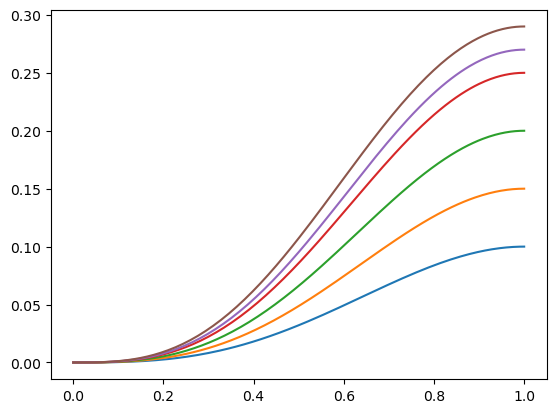

In [ ]:
C_chosen = [0.1, 0.15, 0.2, 0.25, 0.27, 0.29]
for i, C in enumerate(C_chosen):
    print(f"Index: {i}, C: {C}")
    profile = profiles[C]
    activate_profile(profile)
    
    r_match = 1.01 * profile["R"]
    re_test, im_test, grid = scan_cf((0.1, 3), (-2,0.0), 100, 100, r_match, bg_tab, N=500)
    plt.figure(figsize=(6,5))
    plt.imshow(
        grid.T,
        extent=[re_test[0], re_test[-1], im_test[0], im_test[-1]],
        origin='lower',
        aspect='auto',
        cmap='viridis',
    )
    plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
    plt.xlabel(r'Re$(\omega )$')
    plt.ylabel(r'Im$(\omega )$')
    plt.title(f'QNM CF residual scan (even parity), C={C:.3f}')
    plt.show()

    np.savez(f"param_scan_C_{C:.3f}.npz", re_test=re_test, im_test=im_test, grid=grid)
    del re_test, im_test, grid


In [38]:
r_match = 1.1*R

In [12]:

@njit
def allocate_cf_workspace(N):
    alpha = np.empty(N+2, dtype=np.complex128)
    beta  = np.empty(N+2, dtype=np.complex128)
    gamma = np.empty(N+2, dtype=np.complex128)
    delta = np.empty(N+2, dtype=np.complex128)

    a = np.empty(N+2, dtype=np.complex128)
    b = np.empty(N+2, dtype=np.complex128)
    c = np.empty(N+2, dtype=np.complex128)

    return alpha, beta, gamma, delta, a, b, c

@njit
def initial_coeffs(QR, dQR, r, M, om):
    f = 1.0 - 2.0*M/r

    chi_r = (r/(2.0*M) - 1.0)**(-2j*M*om) * np.exp(-1j*om*r)

    a0 = QR / chi_r
    a1 = (r / chi_r) * (dQR + (1j*om*r/(r - 2.0*M)) * QR)

    return a0, a1

@njit
def rw_recurrence(n, r, om, M, l):
    alpha_n = (1.0 - 2.0*M/r) * (n*(n+1))
    beta_n  = -2.0 * (1j*om*r + (1.0 - 3.0*M/r)*n) * n
    gamma_n = (1.0 - 6.0*M/r)*n*(n-1) + 6.0*M/r - l*(l+1)
    delta_n = (2.0*M/r) * (n-3)*(n+1)

    return alpha_n, beta_n, gamma_n, delta_n

@njit
def reduce_to_three_term_inplace(alpha, beta, gamma, delta, a, b, c, N):
    a[:] = alpha
    b[:] = beta
    c[:] = gamma

    for n in range(2, N):
        factor = delta[n] / c[n-1]
        b[n] = beta[n] - factor * a[n-1]
        c[n] = gamma[n] - factor * b[n-1]
    return a, b, c

@njit
def cf_residual_ws(
    om, Q, dQ, r, M, l, N,
    alpha, beta, gamma, delta, a, b, c
):
    a0, a1 = initial_coeffs(Q, dQ, r, M, om)
    ratio_int = a1 / a0

    for n in range(N+2):
        alpha[n], beta[n], gamma[n], delta[n] = rw_recurrence(n, r, om, M, l)

    a,b,c = reduce_to_three_term_inplace(alpha, beta, gamma, delta, a, b, c, N+2)

    cf = b[N]
    for n in range(N-1, 1, -1):
        cf = b[n] - a[n]*c[n+1]/cf

    ratio_cf = -c[1] / cf
    return ratio_int - ratio_cf

def scan_cf_new(
    Re_range, Im_range,
    n_re, n_im,
    R,
    bg_tab,
    N=500
):
    r_match = 1.01*R
    Re = np.linspace(*Re_range, n_re)
    Im = np.linspace(*Im_range, n_im)

    grid = np.zeros((n_re, n_im))

 
    alpha, beta, gamma, delta, a, b, c = allocate_cf_workspace(N)
    for i, re in enumerate(tqdm(Re)):
        for j, im in enumerate(Im):
            om = re + 1j*im

            # interior → exterior matching
            sol_surface = EvenSolverNumbaZerilli(om, r_tab, bg_tab)[1]
            ZR, dZR = ZerilliR(om, R, sol_surface, bg_tab)
            QR, dQR = Chandrasekhar(
                om, ZR, dZR, R=R, M=bg_tab['m'][-1]
            )

            # CF residual (workspace version)
            res = cf_residual_ws(
                om, QR, dQR,
                r_match, bg_tab['m'][-1],
                l=2, N=N,
                alpha=alpha, beta=beta,
                gamma=gamma, delta=delta,
                a=a, b=b, c=c
            )

            grid[i, j] = np.log10(abs(res) + 1e-30)
            #grid[i, j] = np.log10(res.real*res.real + res.imag*res.imag + 1e-30) / 2


    return Re, Im, grid


In [49]:
activate_profile(profile=profiles[0.2])

In [53]:
profile['r'][-1] - profile['R']

np.float64(-6.801391227995168e-09)

In [54]:
R_surf = profile['R'] 

In [56]:
1.01*R_surf

np.float64(1.01)

In [59]:
del re_test_new, im_test_new, grid_new, re_test_old, im_test_old, grid_old

In [60]:
re_test_new, im_test_new, grid_new = scan_cf_new((0.1, 2), (-0.5,0.0), 50, 50, R_surf, bg_tab, N=500)
re_test_old, im_test_old, grid_old = scan_cf((0.1, 2), (-0.5,0.0), 50, 50, R_surf, bg_tab, N=500)
print(np.max(np.abs(grid_new - grid_old)))
print(np.allclose(grid_new, grid_old, rtol=1e-10, atol=1e-10))


100%|██████████| 50/50 [19:09<00:00, 23.00s/it]

0.0
True


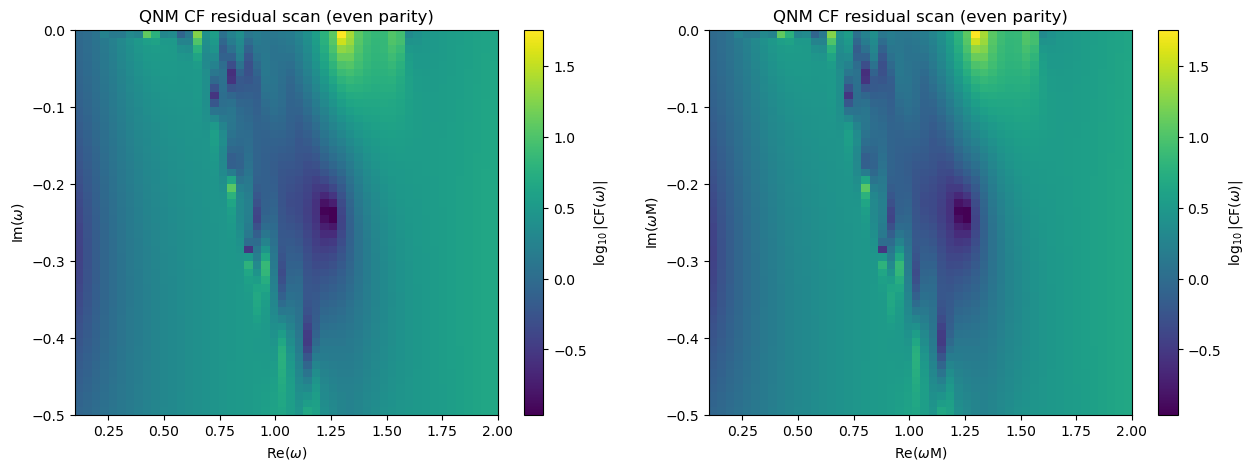

In [62]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
im1 = ax[0].imshow(
    grid_old.T,   # transpose so Im is vertical
    extent=[re_test_old[0], re_test_old[-1], im_test_old[0], im_test_old[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

fig.colorbar(im1, ax=ax[0], label=r'$\log_{10} |{\rm CF}(\omega)|$')
ax[0].set_xlabel(r'Re$(\omega $)')
ax[0].set_ylabel(r'Im$(\omega $)')
ax[0].set_title('QNM CF residual scan (even parity)')

im2 = ax[1].imshow(
    grid_new.T,   # transpose so Im is vertical
    extent=[re_test_new[0], re_test_new[-1], im_test_new[0], im_test_new[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)

fig.colorbar(im2, ax=ax[1], label=r'$\log_{10} |{\rm CF}(\omega)|$')
ax[1].set_xlabel(r'Re$(\omega $M)')
ax[1].set_ylabel(r'Im$(\omega $M)')
ax[1].set_title('QNM CF residual scan (even parity)')
plt.show()

# Parallelization

In [13]:
import os 

In [14]:
def run_scan_for_compactness(C):
    print(f"[PID {os.getpid()}] Starting C = {C:.3f}")

    # activate background
    profile = profiles[C]
    activate_profile(profile)

    R = profile["R"]
    r_match = 1.01 * R

    Re, Im, grid = scan_cf(
        Re_range=(0.1, 3.0),
        Im_range=(-2.0, 0.0),
        n_re=200,
        n_im=200,
        R=R,
        bg_tab=bg_tab,
        N=500
    )

    np.savez(
        f"param_scan_C_{C:.3f}_highres.npz",
        Re=Re,
        Im=Im,
        grid=grid
    )

    print(f"[PID {os.getpid()}] Finished C = {C:.3f}")
    return C


In [16]:
C_chosen = [0.20]

min(len(C_chosen), os.cpu_count())

1

In [84]:
from joblib import Parallel, delayed
import os


Parallel(
    n_jobs=6,   # or min(len(C_chosen), os.cpu_count())
    backend="loky",
    verbose=10
)(
    delayed(run_scan_for_compactness)(C)
    for C in C_chosen
)


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed: 315.0min remaining: 630.0min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed: 315.1min remaining: 315.1min
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed: 315.4min remaining: 157.7min
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed: 315.9min finished


[0.1, 0.15, 0.2, 0.25, 0.27, 0.29]

In [68]:
os.cpu_count()

24

In [85]:
for C in C_chosen:
    data = np.load(f"param_scan_C_{C:.3f}.npz")
    print(C, data["grid"].shape, np.min(data["grid"]))
    del data


0.1 (50, 50) -0.39427680244773705
0.15 (50, 50) -0.7786581932897599
0.2 (50, 50) -0.8611495171755699
0.25 (50, 50) -0.5430161763642626
0.27 (50, 50) -0.43343599037904357
0.29 (50, 50) -1.4691449507411702


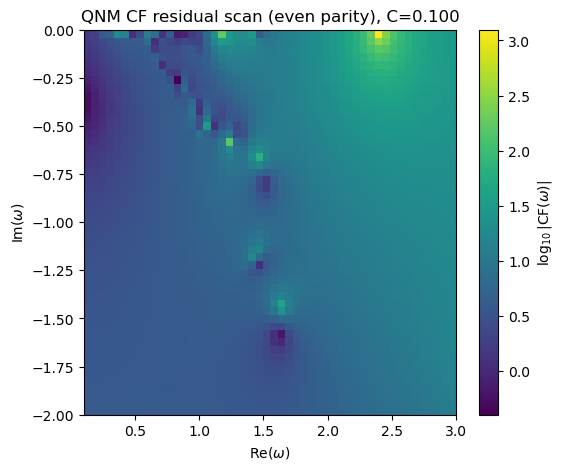

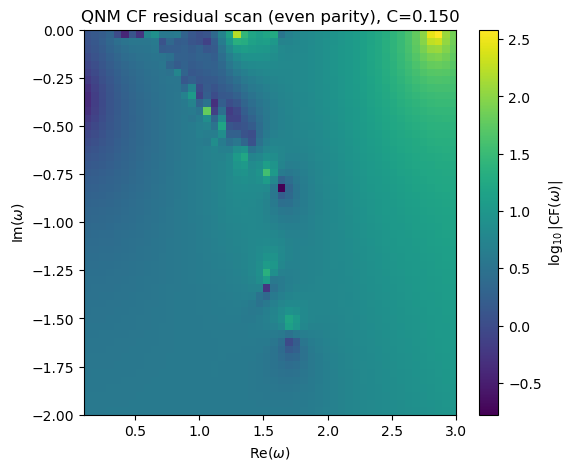

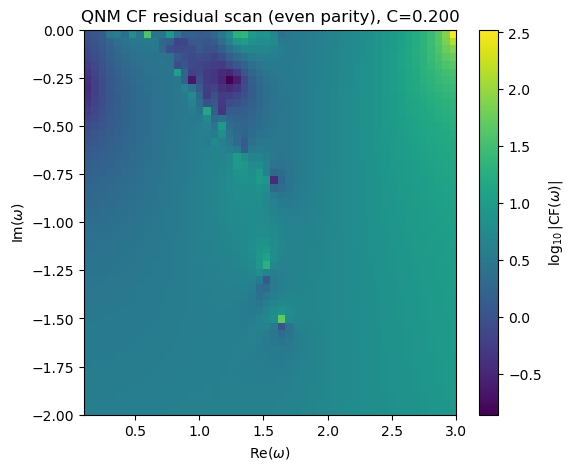

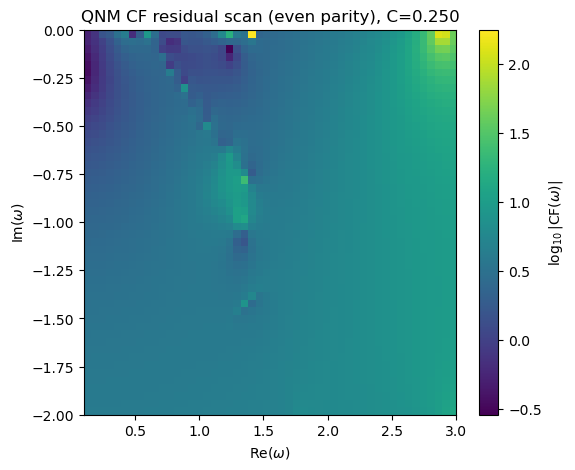

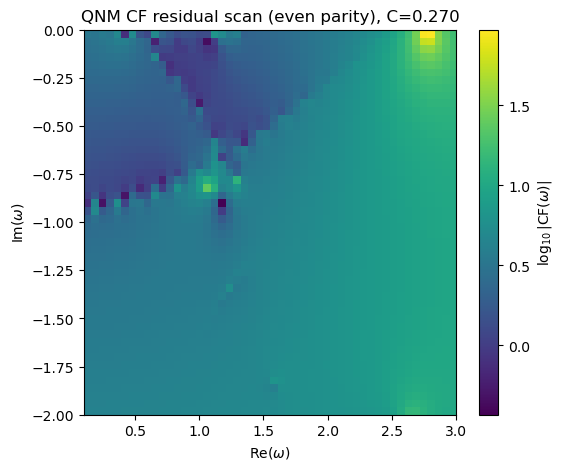

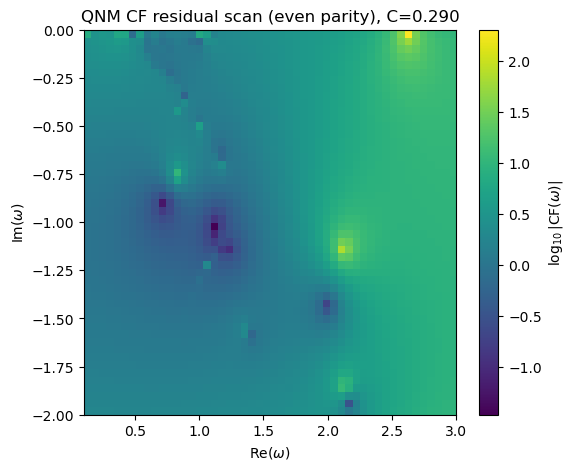

In [74]:
for C in C_chosen:
    data = np.load(f"param_scan_C_{C:.3f}.npz")
    plt.figure(figsize=(6,5))
    plt.imshow(
        data["grid"].T,
        extent=[data["Re"][0], data["Re"][-1], data["Im"][0], data["Im"][-1]],
        origin='lower',
        aspect='auto',
        cmap='viridis',
    )
    plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
    plt.xlabel(r'Re$(\omega )$')
    plt.ylabel(r'Im$(\omega )$')
    plt.title(f'QNM CF residual scan (even parity), C={C:.3f}')
    plt.show()
    del data


In [75]:
data = np.load(f"param_scan_C_0.200.npz")
idx = np.unravel_index(np.argmin(data["grid"]), data["grid"].shape)
print("Min CF residual at:", data["Re"][idx[0]], data["Im"][idx[1]])

Min CF residual at: 1.2244897959183674 -0.24489795918367352


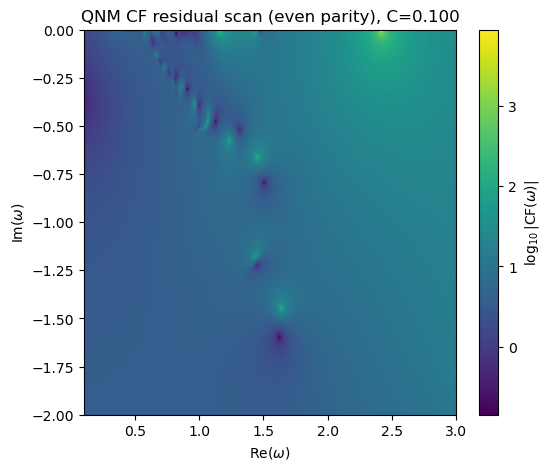

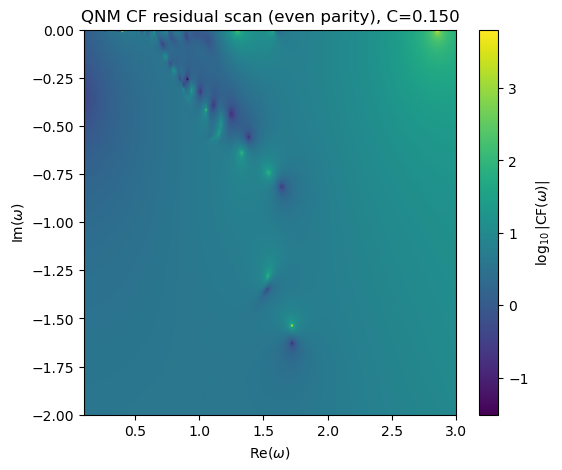

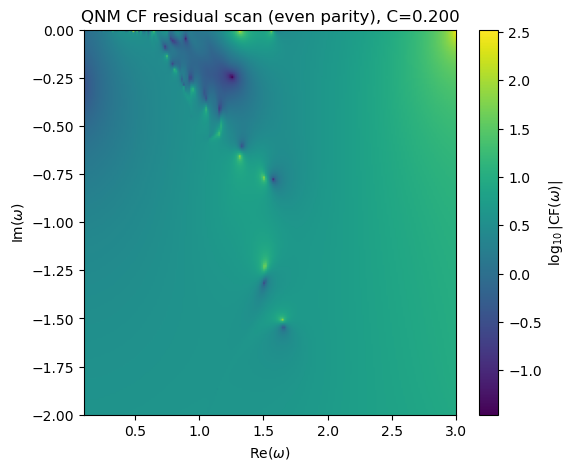

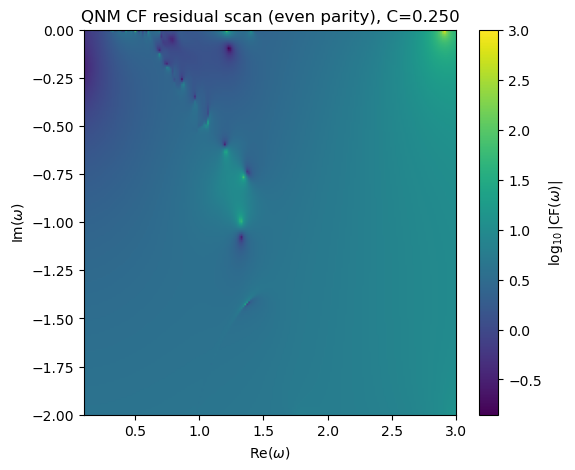

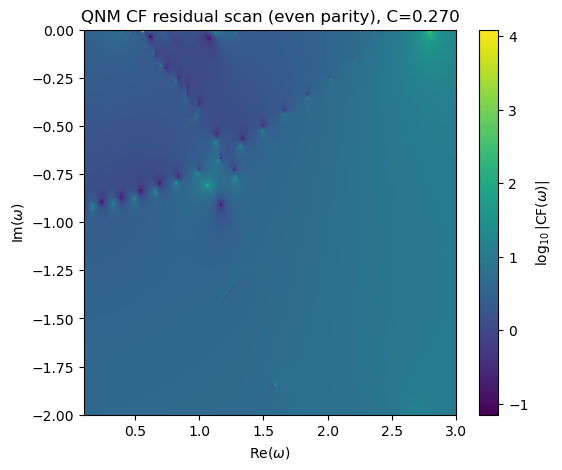

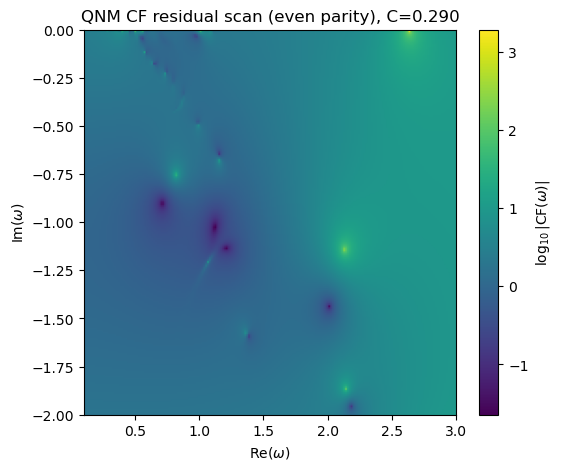

In [ ]:
data = {}
for i, C in enumerate(C_chosen):
    data[i] = np.load(f"param_scan_C_{C:.3f}_highres.npz")
    plt.figure(figsize=(6,5))
    plt.imshow(
        data[i]["grid"].T,
        extent=[data[i]["Re"][0], data[i]["Re"][-1], data[i]["Im"][0], data[i]["Im"][-1]],
        origin='lower',
        aspect='auto',
        cmap='viridis',
    )
    plt.colorbar(label=r'$\log_{10} |{\rm CF}(\omega)|$')
    plt.xlabel(r'Re$(\omega )$')
    plt.ylabel(r'Im$(\omega )$')
    
    plt.title(f'QNM CF residual scan (even parity), C={C:.3f}')
    plt.show()
    


In [34]:
1/3.77

0.26525198938992045

In [22]:
bg_tab = make_bg_tables(bg, r_tab)

def EvenSolverNumbaZerilliTest(omega, r_grid, bg_tab, source=SourceTensor(), eps=1e-6):
    om = omega
    y0 = init_conds_even_perfect(eps, om)

    bgarray = pack_bg_quantities(bg_tab)
    source_tab = make_source(source, r_grid, omega)
    sourcearray = pack_source(source_tab)

    sol = solve_ivp(
        lambda r, y: even_wrapper(
            r, y,
            omega,
            r_grid,
            bgarray,
            sourcearray
        ),
        (eps, r_end),
        y0,
        method='RK45',
        rtol=1e-7,
        atol=1e-10,
        max_step=1e-3
    )


    if not sol.success:
        raise RuntimeError(f"integrator failed: {sol.message}")

    return sol.t, sol.y

In [31]:
activate_profile(profile=profiles[0.2])
om_test = 1.22918595-0.24531493j#0.5 - 0.2j #0.78079428-0.17216419j#
rtest, soltest = EvenSolverNumbaZerilliTest(om_test, r_grid=r_tab, bg_tab=bg_tab)

In [32]:
XhR = soltest[0] + 1j * soltest[1]

X_norm = abs(XhR[-1]) / np.max(np.abs(XhR))
print("Norm at outer boundary:", X_norm)

Norm at outer boundary: 1.8130874189426428e-07


Norm at outer boundary: 1.8130874189426428e-07

In [27]:
muller_init(1.2686363015663733-0.4351687730141169j, tol=1e-10, max_iter=100, N=800)

 0 | ω = 1.39593960-0.44537917j | |CF| = 1.842e+00
 1 | ω = 1.27380650-0.30503836j | |CF| = 5.120e-01
 2 | ω = 1.22743913-0.27976682j | |CF| = 2.353e-01
 3 | ω = 1.22576075-0.24212399j | |CF| = 2.787e-02
 4 | ω = 1.22867465-0.24464956j | |CF| = 5.445e-03
 5 | ω = 1.22917882-0.24540598j | |CF| = 6.199e-04
 6 | ω = 1.22914677-0.24532038j | |CF| = 4.831e-05
 7 | ω = 1.22915213-0.24532449j | |CF| = 9.411e-06
 8 | ω = 1.22915347-0.24532535j | |CF| = 4.805e-07
 9 | ω = 1.22915354-0.24532541j | |CF| = 2.742e-08
10 | ω = 1.22915354-0.24532540j | |CF| = 6.319e-09
11 | ω = 1.22915354-0.24532540j | |CF| = 1.611e-10
12 | ω = 1.22915354-0.24532540j | |CF| = 4.706e-11


np.complex128(1.2291535375875962-0.24532540485297252j)

In [30]:
np.abs(1.2686363015663733-0.4351687730141169j) - (1.2291535375875962-0.24532540485297252j)

np.complex128(0.11204366143222666+0.24532540485297252j)

# QNM C sweep

In [23]:
qnm = []
for i, C in enumerate(C_chosen):
    activate_profile(profile=profiles[C])
    M = profiles[C]["M"]
    qnm.append(muller_init(1.2 - 0.2j, tol=1e-10, max_iter=100, N=800))
    print(f"C={C:.3f}, QNM: {qnm[-1]}, ωM: {qnm[-1]*M}")


 0 | ω = 1.03682406-0.22743528j | |CF| = 4.248e+00
 1 | ω = 0.95005782-0.19997426j | |CF| = 3.590e+00
 2 | ω = 0.83134316-0.06868348j | |CF| = 2.799e+00
 3 | ω = 0.59256977-0.06094962j | |CF| = 3.591e+00
 4 | ω = 0.70381202-0.08305706j | |CF| = 3.177e+00
 5 | ω = 0.63858815-0.06916283j | |CF| = 9.291e-01
 6 | ω = 0.63278331-0.05670150j | |CF| = 3.161e-01
 7 | ω = 0.62797157-0.05844103j | |CF| = 4.016e-01
 8 | ω = 0.63066491-0.05788154j | |CF| = 1.136e-02
 9 | ω = 0.63074320-0.05785209j | |CF| = 3.104e-04
10 | ω = 0.63074114-0.05785293j | |CF| = 4.549e-06
11 | ω = 0.63074115-0.05785296j | |CF| = 2.806e-06
12 | ω = 0.63074117-0.05785301j | |CF| = 8.022e-07
13 | ω = 0.63074116-0.05785301j | |CF| = 1.117e-06
14 | ω = 0.63074117-0.05785301j | |CF| = 9.489e-08
15 | ω = 0.63074117-0.05785301j | |CF| = 5.960e-08
16 | ω = 0.63074117-0.05785301j | |CF| = 2.860e-08
17 | ω = 0.63074117-0.05785301j | |CF| = 3.960e-09
18 | ω = 0.63074117-0.05785301j | |CF| = 6.409e-10
19 | ω = 0.63074117-0.05785301j

In [24]:
qnm

[np.complex128(0.6307411659664043-0.05785301093322009j),
 np.complex128(0.894724686501853-0.025586363676567126j),
 np.complex128(1.2291535375793117-0.24532540485474139j),
 np.complex128(1.2252025028746356-0.0986214779754777j),
 np.complex128(1.1418870837896438-0.06020419559010157j),
 np.complex128(0.29069065492551815-0.8341484943585795j)]

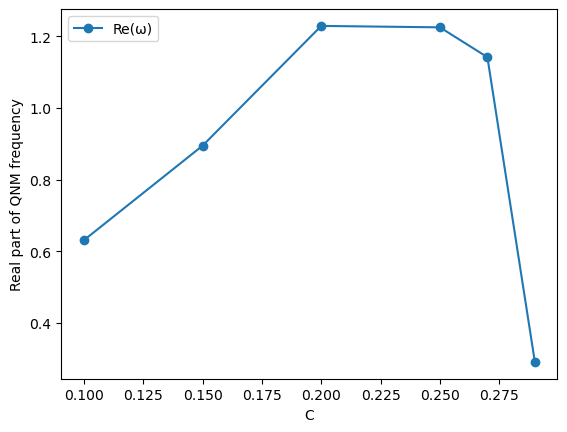

In [25]:
plt.plot([C for C in C_chosen], [om.real for om in qnm], 'o-', label='Re(ω)')
plt.xlabel('C')
plt.ylabel('Real part of QNM frequency')
plt.legend()
plt.show()

Text(0, 0.5, 'Imaginary part of QNM frequency')

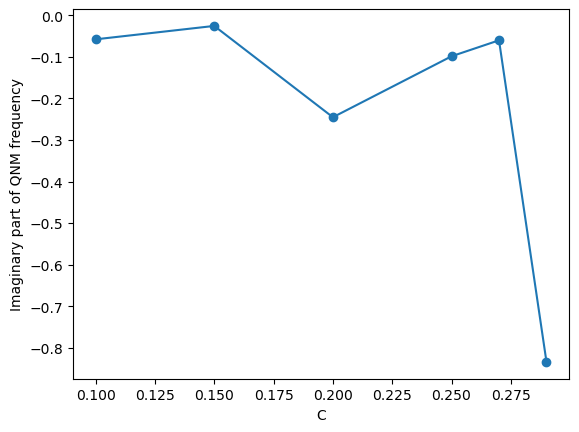

In [28]:
plt.plot([C for C in C_chosen], [om.imag for om in qnm], 'o-',label='Im(ω)')
plt.xlabel('C')
plt.ylabel('Imaginary part of QNM frequency')

In [33]:
(1.2291535375793117-0.24532540485474139j)*0.2

(0.24583070751586233-0.04906508097094828j)

In [35]:
activate_profile(profiles[0.2])

In [ ]:
profile = profiles[0.2]
profile[]

KeyError: 'rho'

# TOV rest mass poly fixed

1.0 1.0624678136316401 0.9412049825602549
1.0 1.041043593428061 0.9605745679747105
1.0 1.0190466607443585 0.9813093340294684
1.0 0.9964198158003796 1.0035930479732025
1.0 0.9730939360506599 1.0276500170770146
1.0 0.9489848902476623 1.053757557445434
1.0 0.9239879513938503 1.0822651945747608
1.0 0.8979700749528704 1.1136228565884945
1.0 0.870756642320798 1.1484264964488058
1.0 0.8421100003825372 1.1874933198106419
1.0 0.8116905051773297 1.231996670678722
1.0 0.7789787505893444 1.283732064890653
1.0 0.7430989133022416 1.345715869178332
1.0 0.7023191287278573 1.423854141366398


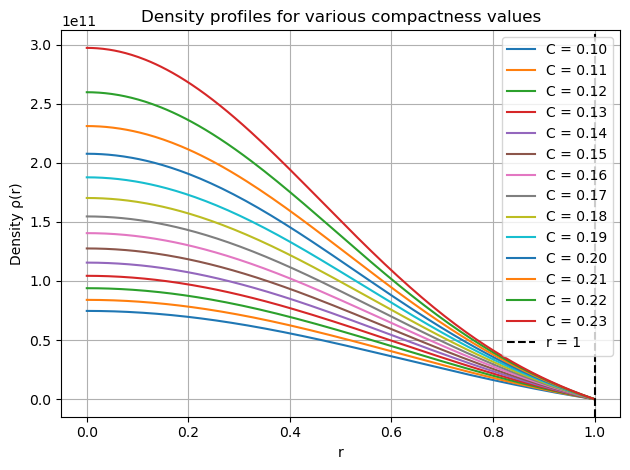

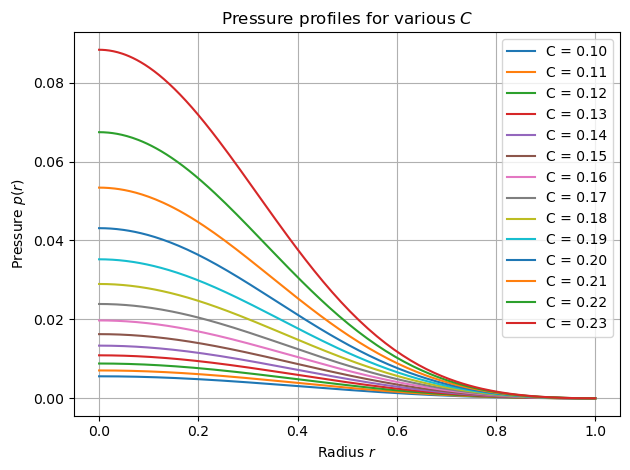

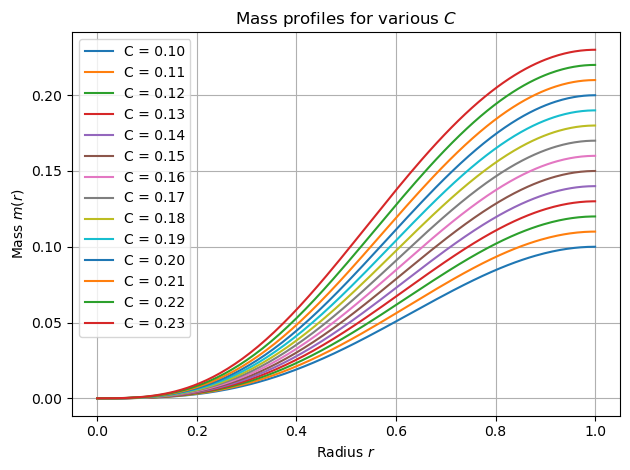

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.interpolate import InterpolatedUnivariateSpline, CubicSpline, interp1d
import matplotlib.pyplot as plt
import cmath as cm

# Constants
K = 1.0             # Polytropic constant (dimensionless)
R_target = 1.0      # Target rescaled stellar radius
n = 1                # Polytropic index


"""def rho_from_p(p):
    p = np.maximum(p, 0.0)
    return pow((p / K),0.5) #np.sqrt(p / K)"""

def rho_from_p(p):
    return np.sqrt(np.maximum(p, 0.0) / K)

def energy_density_from_p(p):
    rho0 = rho_from_p(p)
    Gamma = 1 + 1/n
    return rho0 + (p/(Gamma-1))  # Total energy density for polytropic EOS


def tov_rhs(r, y):
    p, m, nu = y

    if p <= 0.0:
        return [0.0, 0.0, 0.0]

    rho0 = rho_from_p(p)
    eps  = energy_density_from_p(p) #rho0 + p  # total energy density

    dpdr = -(eps + p) * (m + 4*np.pi*r**3*p) / (r*(r - 2*m))
    dmdr = 4*np.pi * r**2 * eps
    dnudr = -2 * dpdr / (eps + p)

    return [dpdr, dmdr, dnudr]


# Solve TOV for a given p0
def solve_tov(p0):
    y0 = [p0, 0.0,0.0]
    sol = solve_ivp(
        tov_rhs,
        [1e-6, 10],  # integrate far enough to catch where p=0
        y0,
        method='RK45',
        rtol=1e-10,
        atol=1e-12,
        dense_output=True
    )
    r_vals = sol.t
    p_vals = sol.y[0]
    m_vals = sol.y[1]

    # Find where pressure becomes zero and interpolate to find R more accurately
    for i in range(1, len(p_vals)):
        if p_vals[i] <= 0:
            r1, r2 = r_vals[i-1], r_vals[i]
            p1, p2 = p_vals[i-1], p_vals[i]
            R_interp = r1 + (0 - p1) * (r2 - r1) / (p2 - p1)
            M_interp = m_vals[i-1] + (0 - p1) * (m_vals[i] - m_vals[i-1]) / (p2 - p1)
            return R_interp, M_interp, sol
    return r_vals[-1], m_vals[-1], sol  # fallback

# Shooting function to match compactness C = M/R
def shooting_target(p0, C_target):
    R, M, _ = solve_tov(p0)
    return M / R - C_target

# Define the values of compactness to solve for
C_vals = np.round(np.arange(0.10, 0.24, 0.01), 2)
profiles = {}

for C_target in C_vals:
    soln = root_scalar(
        shooting_target,
        args=(C_target,),
        bracket=[1e-6, 1.0],
        method='brentq',
        xtol=1e-12
    )

    if not soln.converged:
        raise RuntimeError(f"Root finding failed for C = {C_target}")

    p0 = soln.root
    R_raw, M_raw, sol = solve_tov(p0)
    scale_factor = R_target / R_raw
    print(R_target, R_raw, scale_factor)

    scale_factor = R_target / R_raw  # alpha

    r_vals = sol.t * scale_factor           # r -> alpha * r   (correct)
    p_vals = sol.y[0] * scale_factor**(-2)  # p -> alpha^{-2} * p    <-- FIXED
    m_vals = sol.y[1] * scale_factor        # m -> alpha * m         (correct)
    rho_vals = rho_from_p(p_vals)           # consistent with p
    nu_vals = sol.y[2]
    # Truncate where p goes to zero
    mask = p_vals > 0
    r_vals = r_vals[mask]
    p_vals = p_vals[mask]
    m_vals = m_vals[mask]
    rho_vals = rho_vals[mask]
    nu_vals = nu_vals[mask]

    R = R_raw * scale_factor
    M = M_raw * scale_factor

    if 2.0 * M / R >= 1.0:
        raise ValueError(f"Unphysical compactness encountered for C = {C_target}: 2M/R >= 1")

    nu_target_surface = np.log(1.0 - 2.0 * M / R)
    nu_raw_surface = nu_vals[-1]

    # Compute constant shift Δν
    delta_nu = nu_target_surface - nu_raw_surface

    # Apply the shift to entire profile
    nu_vals_normalized = nu_vals + delta_nu


    profiles[C_target] = {
        'r': r_vals,
        'r_raw': R_raw,
        'p': p_vals,
        'm': m_vals,
        'rho': rho_vals,
        'nu': nu_vals,
        'nu_vals_norm': nu_vals_normalized,
        'p0': p0,
        'R': R_raw * scale_factor,
        'M': M_raw * scale_factor,
        'M_raw': M_raw
    }


for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['rho']*1e12, label=f'C = {C:.2f}')
plt.axvline(1.0, color='black', linestyle='--', label='r = 1')
plt.xlabel('r')
plt.ylabel('Density ρ(r)')
plt.title('Density profiles for various compactness values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Pressure
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,2)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['p'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Pressure $p(r)$')
plt.title('Pressure profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Mass
#plt.figure(figsize=(10, 6))
#plt.subplot(3,1,3)
for C in C_vals:
    plt.plot(profiles[C]['r'], profiles[C]['m'], label=f'C = {C:.2f}')
plt.xlabel('Radius $r$')
plt.ylabel('Mass $m(r)$')
plt.title('Mass profiles for various $C$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

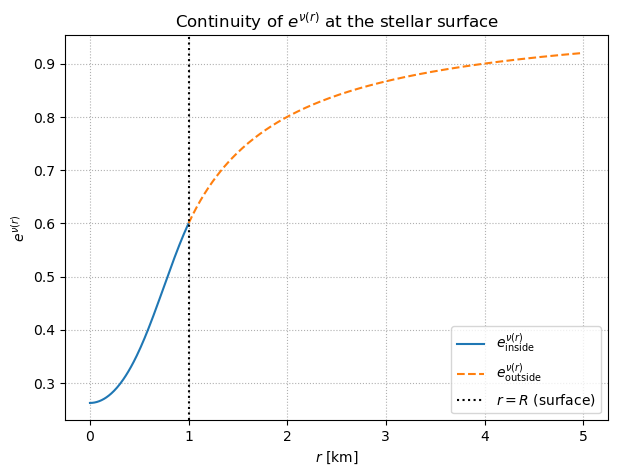

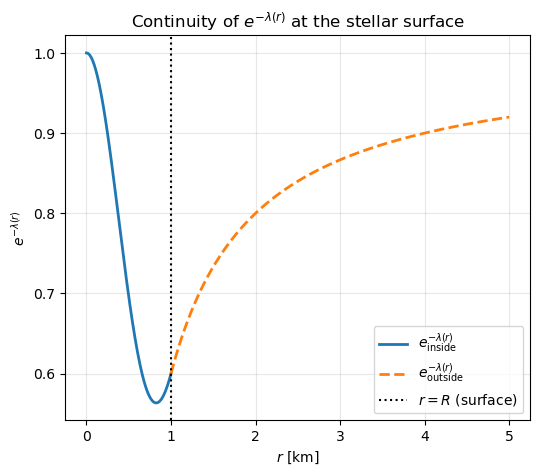

In [2]:
import numpy as np
import matplotlib.pyplot as plt
C = 0.2

M = profiles[C]['M']
R = profiles[C]['R']
nu_in = profiles[C]['nu_vals_norm']
r_in = profiles[C]['r']
m = profiles[C]['m']

def nu_out(r):
    return np.log(1 - 2*M/r)


exp_nu_in = np.exp(nu_in)
r_out = np.linspace(R, 5*R, 200)
exp_nu_out = np.exp(nu_out(r_out))


plt.figure(figsize=(7,5))
plt.plot(r_in, exp_nu_in, label=r'$e^{\nu(r)}_{\mathrm{inside}}$', color='tab:blue')
plt.plot(r_out, exp_nu_out, label=r'$e^{\nu(r)}_{\mathrm{outside}}$', color='tab:orange', linestyle='--')

plt.axvline(R, color='k', linestyle=':', label=r'$r=R$ (surface)')
plt.xlabel(r'$r$ [km]')
plt.ylabel(r'$e^{\nu(r)}$')
plt.title('Continuity of $e^{\\nu(r)}$ at the stellar surface')
plt.legend()
plt.grid(True, ls=':')
plt.show()


elam_inside = 1 - 2 * m / r_in

r_out = np.linspace(R, 5 * R, 200)
elam_outside = 1 - 2 * M / r_out

plt.figure(figsize=(6,5))
plt.plot(r_in, elam_inside, label=r"$e^{-\lambda(r)}_{\rm inside}$", lw=2)
plt.plot(r_out, elam_outside, '--', label=r"$e^{-\lambda(r)}_{\rm outside}$", lw=2)
plt.axvline(R, color='k', ls=':', label=r"$r = R$ (surface)")
plt.xlabel(r"$r$ [km]")
plt.ylabel(r"$e^{-\lambda(r)}$")
plt.title(r"Continuity of $e^{-\lambda(r)}$ at the stellar surface")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
